# ForesightEstate — исследование, подготовка и модели

Главный ноутбук проекта: этап 1 — исследование данных, этап 2 — предварительная обработка, этап 3 — базовое сравнение 13 моделей регрессии.

Запускайте ячейки сверху вниз из корня проекта или из папки `notebooks`. Исходный CSV загружается один раз. Для перевода цен используются сохранённые курсы TCMB; если файла курсов нет, первый запуск потребует интернет.

## Краткая схема работы

| Шаг | Результат |
| --- | --- |
| Исследование | Проверены 403 487 объявлений и 17 исходных столбцов. |
| Подготовка | Цены предполагаемых продаж приведены к TRY, аномалии проверены по правилам, рассчитан train/validation/test. |
| Модели | Сравниваются 13 базовых алгоритмов на одной выборке: 8 000 train и 3 000 validation. Test не используется для обучения и подбора параметров. |

Целевая переменная — **цена объявления в TRY**, а не подтверждённая цена сделки. Код `listing_type=1` рассматривается как продажа по масштабу цен; исходный словарь не расшифровывает этот код. Результат текущего этапа — базовое сравнение; подбор параметров и выбор финальной модели будут следующим шагом.

# Этап 1. Исследование данных (EDA)

**Задача проекта:** прогнозировать цену жилой недвижимости по характеристикам объявления. Здесь мы изучаем данные до очистки и обучения моделей. Таблицы и графики строятся из файла `data/real_estate_data.csv`; исходный файл не меняется.

**Как читать ноутбук:** после каждой таблицы и каждого графика идёт простое пояснение. Числа относятся к историческим объявлениям, а не к фактическим ценам сделок.

## 1.1. Знакомство с данными

Источник — набор объявлений Zingat; описание полей находится в `data/zingat_data_info.docx`. Целевая переменная — `price` с единицей `price_currency`. Площадь `size` дана в м², `tom` — в днях. `building_age` означает возраст здания, а не год постройки. `address` записан как город/район/микрорайон.

# Описание данных

Имена полей приведены как в CSV; значения переводятся только при показе. Исходный файл не меняется.

| Поле | Что означает |
|---|---|
| id | Уникальный номер объявления. |
| type | Общий тип недвижимости: Konut — жильё. |
| sub_type | Подтип: квартира, вилла, отдельный дом и др. |
| start_date | Дата публикации; исходный формат месяц/день/год. |
| end_date | Дата снятия объявления; может быть пустой. |
| listing_type | Код типа объявления. По ценам 1 предположительно продажа, 2 аренда; словарь не подтверждает коды. Код 3 не интерпретируем. |
| tom | Срок объявления на рынке, дни; для прогноза при публикации недоступен. |
| building_age | Возраст здания в годах или интервал, например 6-10 arası — от 6 до 10 лет. Это не год постройки. |
| total_floor_count | Этажность здания; бывают диапазоны и значения «20 и более». |
| floor_no | Этаж объекта; Yüksek Giriş — высокий первый этаж. |
| room_count | Формат 2+1: две комнаты и гостиная. |
| size | Площадь, м². |
| address | Город/район/микрорайон. Собственные имена не переводим. |
| furnished | Меблировка; в этом файле столбец полностью пуст. |
| heating_type | Тип отопления; Kombi (Doğalgaz) — газовый котёл. |
| price | Цена объявления, целевая переменная. |
| price_currency | TRY — турецкая лира, EUR — евро, GBP — фунт, USD — доллар США. |

Краткий словарь: Daire — квартира; Villa — вилла; Müstakil Ev — отдельный дом; Rezidans — резиденция; Yazlık — летний дом; Komple Bina — здание целиком; Prefabrik Ev — сборный дом; Çiftlik Evi — фермерский дом; Kooperatif — кооперативное жильё; Loft — лофт. arası означает «от … до …», ve üzeri — «и более».


In [2]:
# Загружаем данные; путь работает из корня проекта и из папки notebooks.
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 30)
RANDOM_STATE = 42
DATA_PATH = next((p for p in [Path("data/real_estate_data.csv"), Path("../data/real_estate_data.csv")] if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Не найден data/real_estate_data.csv")
df = pd.read_csv(DATA_PATH, low_memory=False)
original_columns = df.columns.tolist()

# Переводы используются только для показа; df и sale остаются с исходными значениями.
COLUMN_RU={"id":"Номер (id)","type":"Тип (type)","sub_type":"Подтип жилья (sub_type)",
"start_date":"Дата публикации (start_date)","end_date":"Дата снятия (end_date)",
"listing_type":"Тип объявления (listing_type)","tom":"Дней на рынке (tom)",
"building_age":"Возраст здания (building_age)","total_floor_count":"Этажей в здании (total_floor_count)",
"floor_no":"Этаж (floor_no)","room_count":"Комнаты (room_count)","size":"Площадь, м² (size)",
"address":"Адрес (address)","furnished":"Меблировка (furnished)",
"heating_type":"Отопление (heating_type)","price":"Цена (price)",
"price_currency":"Валюта (price_currency)"}
TYPE_RU={"Konut":"Жильё"}
SUBTYPE_RU={"Daire":"Квартира","Villa":"Вилла","Müstakil Ev":"Отдельный дом",
"Rezidans":"Резиденция","Yazlık":"Летний дом","Komple Bina":"Здание целиком",
"Prefabrik Ev":"Сборный дом","Çiftlik Evi":"Фермерский дом",
"Köşk / Konak / Yalı":"Особняк / усадьба / прибрежный дом",
"Yalı Dairesi":"Квартира в прибрежном доме","Kooperatif":"Кооперативное жильё","Loft":"Лофт"}
AGE_RU={f"{a}-{b} arası":f"{a}–{b} лет" for a,b in [(6,10),(11,15),(16,20),(21,25),(26,30),(31,35),(36,40)]}
AGE_RU["40 ve üzeri"]="40 лет и старше"
FLOOR_RU={"Yüksek Giriş":"Высокий первый этаж","Giriş kat":"Первый этаж",
"Zemin kat":"Нулевой этаж","Bahçe katı":"Садовый этаж","Çatı Katı":"Мансардный этаж"}
HEATING_RU={"Fancoil":"Фанкойл","Klima":"Кондиционер","Yok":"Нет отопления",
"Kombi (Doğalgaz)":"Газовый котёл","Kombi (Elektrikli)":"Электрический котёл",
"Kalorifer (Doğalgaz)":"Центральное газовое отопление",
"Kalorifer (Kömür)":"Центральное угольное отопление",
"Merkezi Sistem":"Центральное отопление",
"Merkezi Sistem (Isı Payı Ölçer)":"Центральное отопление со счётчиком",
"Yerden Isıtma":"Тёплый пол","Soba (Kömür)":"Угольная печь",
"Soba (Doğalgaz)":"Газовая печь","Güneş Enerjisi":"Солнечная энергия",
"Jeotermal":"Геотермальное отопление","Kat Kaloriferi":"Поквартирное отопление",
"Kalorifer (Akaryakıt)":"Жидкотопливное отопление"}
FLOOR_RU.update({"20 ve üzeri":"20 и более","Kot 1":"Цокольный уровень 1",
"Kot 2":"Цокольный уровень 2","Kot 3":"Цокольный уровень 3",
"Kot 4":"Цокольный уровень 4","Asma Kat":"Антресоль",
"Müstakil":"Отдельный дом","Zemin Kat":"Нулевой этаж",
"En Üst Kat":"Верхний этаж","Giriş Katı":"Входной этаж",
"Çatı Katı":"Мансардный этаж","Teras Kat":"Террасный этаж",
"Komple":"Здание целиком","Bodrum Kat":"Подвальный этаж"})
FLOOR_COUNT_RU={"20 ve üzeri":"20 и более","10-20 arası":"10–20"}
def show_ru(frame):
    shown=frame.copy()
    for col,dictionary in [("type",TYPE_RU),("sub_type",SUBTYPE_RU),
                           ("building_age",AGE_RU),("total_floor_count",FLOOR_COUNT_RU),("floor_no",FLOOR_RU),
                           ("heating_type",HEATING_RU)]:
        if col in shown.columns:
            shown[col]=shown[col].replace(dictionary)
    return shown.rename(columns=COLUMN_RU)
print(f"Размер: {len(df):,} строк × {len(original_columns)} столбцов")

def show_table(frame):
    # Показываем плоскую таблицу без технического числового индекса.
    display(frame.style.hide(axis="index").format(precision=2, thousands=" ", na_rep="—"))


Размер: 403,487 строк × 17 столбцов


в датасете 403 487 объявлений и 17 исходных признаков. Это достаточно большая выборка для сравнения групп, но качество каждого поля нужно проверить отдельно.

### Типы и заполненность полей

In [3]:
# Таблица показывает формат, число заполненных и число уникальных значений.
schema = pd.DataFrame({"тип": df.dtypes.astype(str),
                       "заполнено": df.notna().sum(),
                       "уникальных": df.nunique(dropna=True)})
show_table(schema.rename(index=COLUMN_RU).rename_axis("Поле").reset_index())

Поле,тип,заполнено,уникальных
Номер (id),int64,403 487,403 487
Тип (type),object,403 487,1
Подтип жилья (sub_type),object,403 487,12
Дата публикации (start_date),object,403 487,181
Дата снятия (end_date),object,266 298,181
Тип объявления (listing_type),int64,403 487,3
Дней на рынке (tom),int64,403 487,181
Возраст здания (building_age),object,376 097,14
Этажей в здании (total_floor_count),object,375 466,12
Этаж (floor_no),object,368 191,35


`price` и `size` числовые, но `building_age`, `room_count`, этажи и даты пока записаны строками. `type` имеет одно значение — «Konut» (жильё); `furnished` вообще не заполнен. Строковые поля потребуется преобразовать перед обучением.

### Примеры записей

In [4]:
# Первые строки позволяют увидеть исходный формат.
show_table(show_ru(df.head(5)).reset_index(drop=True))

Номер (id),Тип (type),Подтип жилья (sub_type),Дата публикации (start_date),Дата снятия (end_date),Тип объявления (listing_type),Дней на рынке (tom),Возраст здания (building_age),Этажей в здании (total_floor_count),Этаж (floor_no),Комнаты (room_count),"Площадь, м² (size)",Адрес (address),Меблировка (furnished),Отопление (heating_type),Цена (price),Валюта (price_currency)
1,Жильё,Резиденция,12/10/18,1/9/19,2,30,0,20 и более,2,2+1,90.00,İstanbul/Kartal/Kordonboyu,—,Фанкойл,3 500.00,TRY
2,Жильё,Квартира,2/13/19,—,1,14,0,20 и более,20 и более,1+0,43.00,İstanbul/Kartal/Kordonboyu,—,Фанкойл,490 000.00,TRY
3,Жильё,Квартира,10/9/18,11/8/18,1,30,0,1,Высокий первый этаж,2+1,—,Tekirdağ/Çorlu/Reşadiye,—,Фанкойл,155 000.00,TRY
4,Жильё,Резиденция,9/10/18,10/10/18,1,30,3,20 и более,20 и более,6+1,450.00,İstanbul/Beşiktaş/Levent,—,Фанкойл,32 500 000.00,TRY
5,Жильё,Резиденция,12/10/18,1/9/19,1,30,0,20 и более,2,2+1,90.00,İstanbul/Kartal/Kordonboyu,—,Фанкойл,1 450 000.00,TRY


встречаются и низкие, и высокие цены, разные валюты и пустая площадь. Нельзя считать, что все строки описывают один и тот же рынок.

In [5]:
# Последние строки помогают увидеть, одинаков ли формат в конце файла.
show_table(show_ru(df.tail(5)).reset_index(drop=True))

C:\Users\2.0\AppData\Local\Temp\ipykernel_24240\3936902863.py:61: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  shown[col]=shown[col].replace(dictionary)


Номер (id),Тип (type),Подтип жилья (sub_type),Дата публикации (start_date),Дата снятия (end_date),Тип объявления (listing_type),Дней на рынке (tom),Возраст здания (building_age),Этажей в здании (total_floor_count),Этаж (floor_no),Комнаты (room_count),"Площадь, м² (size)",Адрес (address),Меблировка (furnished),Отопление (heating_type),Цена (price),Валюта (price_currency)
403 483,Жильё,Квартира,9/18/18,—,2,162,—,—,—,+,—,İstanbul/Sultanbeyli/Adil,—,—,1 500.00,TRY
403 484,Жильё,Квартира,10/11/18,—,1,139,—,—,—,2+1,—,Sakarya/Adapazarı/Cumhuriyet,—,—,120 000.00,TRY
403 485,Жильё,Квартира,11/22/18,—,1,97,—,—,—,1+1,—,Antalya/Alanya/Saray,—,—,48 000.00,EUR
403 486,Жильё,Квартира,2/21/19,—,2,6,—,—,—,2+1,2.00,Aydın/Kuşadası/Türkmen,—,—,900.00,TRY
403 487,Жильё,Квартира,1/15/19,1/18/19,1,3,—,—,—,3+1,140.00,Kayseri/Melikgazi/Alpaslan,—,—,210 000.00,TRY


структура столбцов сохраняется, но встречаются записи с `room_count='+'` и пропущенной площадью — нужен контроль качества.

In [6]:
# Случайная строка воспроизводима благодаря фиксированному seed.
show_table(show_ru(df.sample(1, random_state=RANDOM_STATE)).reset_index(drop=True))

Номер (id),Тип (type),Подтип жилья (sub_type),Дата публикации (start_date),Дата снятия (end_date),Тип объявления (listing_type),Дней на рынке (tom),Возраст здания (building_age),Этажей в здании (total_floor_count),Этаж (floor_no),Комнаты (room_count),"Площадь, м² (size)",Адрес (address),Меблировка (furnished),Отопление (heating_type),Цена (price),Валюта (price_currency)
60 624,Жильё,Квартира,11/20/18,2/23/19,1,95,6–10 лет,5,1,2+1,120.00,Antalya/Alanya/Oba,—,Кондиционер,240 000.00,TRY


поле `room_count` выглядит как «2+1» (две комнаты и гостиная), а `building_age` может быть диапазоном вроде «6-10 arası».

In [7]:
# Даты публикации парсим в явном формате месяц/день/год.
dates = pd.to_datetime(df.start_date, format="%m/%d/%y", errors="coerce")
print("Период:", dates.min().date(), "—", dates.max().date())
show_table(df.price_currency.value_counts(dropna=False).rename_axis("Валюта").reset_index(name="Объявлений"))

Период: 2018-08-31 — 2019-02-27


Валюта,Объявлений
TRY,400 677
EUR,922
—,715
GBP,621
USD,552


объявления опубликованы с 31.08.2018 по 27.02.2019. Основная валюта — TRY, но также есть EUR, GBP и USD. Цены разных валют без пересчёта сравнивать нельзя; исторический период ограничивает применимость модели к сегодняшнему рынку.

## 1.2. Описательная статистика

Числовая сводка показывает центр распределения и крайние значения. `id` и `listing_type` технически числа, но по смыслу идентификатор и код категории; их среднее значение не интерпретируется.

In [8]:
# Считаем минимум, квартили, медиану, среднее, максимум и стандартное отклонение.
numeric_summary = df.select_dtypes(include="number").describe(percentiles=[.25, .5, .75]).T
show_table(numeric_summary[["count","min","25%","50%","mean","75%","max","std"]].rename(index=COLUMN_RU).rename_axis("Признак").reset_index())

Признак,count,min,25%,50%,mean,75%,max,std
Номер (id),403 487.00,1.00,100 872.50,201 744.00,201 744.00,302 615.50,403 487.00,116 476.81
Тип объявления (listing_type),403 487.00,1.00,1.00,1.00,1.29,2.00,3.00,0.47
Дней на рынке (tom),403 487.00,0.00,29.00,40.00,57.02,90.00,180.00,44.36
"Площадь, м² (size)",257 481.00,1.00,85.00,110.00,279.35,140.00,948 235.00,9 429.20
Меблировка (furnished),0.00,—,—,—,—,—,—,—
Цена (price),402 772.00,-250.00,2 500.00,199 000.00,354 641.66,342 000.00,2 000 000 000.00,4 809 502.70


цена достигает отрицательных значений и экстремально высоких сумм; площадь — до 948 235 м². Поэтому средние сильно зависят от выбросов. Для описания «типичного» объекта полезнее медиана и квартили.

In [9]:
# Считаем число категорий и наиболее частое значение для каждого текстового поля.
categorical_cols = df.select_dtypes(include=["object"]).columns
category_summary = pd.DataFrame({
    "уникальных": df[categorical_cols].nunique(dropna=True),
    "наиболее частое": [df[x].mode(dropna=True).iloc[0] if df[x].notna().any() else None for x in categorical_cols],
    "частота": [df[x].value_counts(dropna=True).iloc[0] if df[x].notna().any() else 0 for x in categorical_cols]
}, index=categorical_cols)
for col,dictionary in [("type",TYPE_RU),("sub_type",SUBTYPE_RU),("building_age",AGE_RU),("heating_type",HEATING_RU)]:
    if col in category_summary.index:
        value=category_summary.loc[col,"наиболее частое"]
        category_summary.loc[col,"наиболее частое"]=dictionary.get(value,value)
show_table(category_summary.rename(index=COLUMN_RU).rename_axis("Поле").reset_index())

Поле,уникальных,наиболее частое,частота
Тип (type),1,Жильё,403 487
Подтип жилья (sub_type),12,Квартира,354 549
Дата публикации (start_date),181,10/11/18,4 064
Дата снятия (end_date),181,12/19/18,3 048
Возраст здания (building_age),14,0,140 174
Этажей в здании (total_floor_count),12,4,83 082
Этаж (floor_no),35,2,65 864
Комнаты (room_count),37,3+1,157 363
Адрес (address),7 842,Balıkesir/Edremit/Akçay,5 611
Отопление (heating_type),16,Газовый котёл,204 150


адрес имеет тысячи значений, поэтому прямое one-hot-кодирование полного адреса будет громоздким. Самый частый тип жилья — квартира (`Daire`), наиболее частая конфигурация — `3+1`. Это стоит учитывать при сравнении средних по группам.

### Частоты важных категорий

In [10]:
# Показываем частоты подтипов жилья.
show_table(df.sub_type.value_counts(dropna=False).rename(index=SUBTYPE_RU).rename_axis("Тип жилья").reset_index(name="Объявлений"))

Тип жилья,Объявлений
Квартира,354 549
Вилла,21 324
Отдельный дом,9 563
Резиденция,7 716
Летний дом,5 929
Здание целиком,2 607
Сборный дом,679
Фермерский дом,528
Особняк / усадьба / прибрежный дом,301
Квартира в прибрежном доме,187


квартир намного больше, чем вилл и других подтипов. Сравнение групп должно сопровождаться числом объявлений, иначе маленькая группа может дать нестабильную оценку.

In [11]:
# Показываем наиболее частые конфигурации комнат.
show_table(df.room_count.value_counts(dropna=False).head(12).rename_axis("Комнаты").reset_index(name="Объявлений"))

Комнаты,Объявлений
3+1,157 363
2+1,138 677
1+1,39 134
4+1,37 472
5+1,8 219
4+2,4 540
5+2,2 926
+,2 898
3+2,2 673
1+0,2 612


`3+1` и `2+1` доминируют. Есть значение `+`, из которого число комнат не извлечь — оно станет пропуском после преобразования.

In [12]:
# Возраст здания бывает числом или интервалом.
show_table(df.building_age.value_counts(dropna=False).rename(index=AGE_RU).rename_axis("Возраст здания").reset_index(name="Объявлений"))

Возраст здания,Объявлений
0,140 174
6–10 лет,50 495
11–15 лет,32 309
16–20 лет,31 333
—,27 390
1,20 355
4,19 032
21–25 лет,18 438
2,17 466
3,15 651


0 лет — самая частая запись; часть возраста дана диапазонами. Точный год постройки в наборе не указан. Ниже диапазоны временно заменяются серединами только для EDA.

### Почему выделяем сопоставимый сегмент

In [13]:
# Сравниваем медианные цены по коду типа объявления и валюте.
show_table(df.groupby(["listing_type","price_currency"],dropna=False).price.agg(["count","median"]).reset_index().rename(columns={"listing_type":"Код объявления","price_currency":"Валюта","count":"Объявлений","median":"Медианная цена"}))

Код объявления,Валюта,Объявлений,Медианная цена
1,EUR,891,85 000.00
1,GBP,581,75 000.00
1,TRY,284 496,270 000.00
1,USD,452,635 000.00
1,—,0,—
2,EUR,31,900.00
2,GBP,40,400.00
2,TRY,113 948,1 200.00
2,USD,99,2 500.00
2,—,0,—


медиана для кода `listing_type=1` и TRY — 270 000, для кода 2 — 1 200. Это согласуется с продажей и арендой соответственно, но числовые коды не объяснены в словаре. Интерпретация кода 1 как продажи остаётся предположением до подтверждения источником.

In [14]:
# Оставляем код 1, TRY и положительные цены; исходный df остаётся неизменным.
sale = df.loc[(df.listing_type == 1) & (df.price_currency == "TRY") & (df.price > 0)].copy()
sale["city"] = sale.address.str.split("/").str[0]
sale["district"] = sale.address.str.split("/").str[1]
sale["rooms"] = pd.to_numeric(sale.room_count.str.split("+", regex=False).str[0], errors="coerce")
age_map = {"6-10 arası":8,"11-15 arası":13,"16-20 arası":18,"21-25 arası":23,
           "26-30 arası":28,"31-35 arası":33,"36-40 arası":38,"40 ve üzeri":42}
sale["age_approx"] = pd.to_numeric(sale.building_age.replace(age_map), errors="coerce")
sale["size_valid"] = sale["size"].where(sale["size"].between(15,1000))
sale["log_price"] = np.log10(sale.price)
print(f"Сопоставимый сегмент: {len(sale):,} объявлений")
sale_summary=sale[["price","size_valid","rooms","age_approx"]].describe(percentiles=[.01,.25,.5,.75,.99]).T
show_table(sale_summary.rename(index={"price":"Цена, TRY","size_valid":"Площадь, м²",
                                   "rooms":"Комнаты","age_approx":"Возраст здания, лет"}).rename_axis("Признак").reset_index())

Сопоставимый сегмент: 284,468 объявлений


Признак,count,mean,std,min,1%,25%,50%,75%,99%,max
"Цена, TRY",284 468.00,491 812.88,5 310 470.76,1.00,63 500.00,185 000.00,270 000.00,420 000.00,3 700 000.00,2 000 000 000.00
"Площадь, м²",182 972.00,127.85,71.76,15.00,45.00,90.00,115.00,145.00,400.00,1 000.00
Комнаты,282 563.00,2.73,1.05,0.00,1.00,2.00,3.00,3.00,6.00,11.00
"Возраст здания, лет",267 492.00,5.86,8.23,0.00,0.00,0.00,2.00,8.00,33.00,42.00


284 468 объявлений с положительной ценой в TRY. Медиана — 270 000 TRY, а среднее — около 492 000 TRY: его поднимают дорогие объявления. Медианная допустимая площадь — 115 м². Отбор площади 15–1000 м² здесь нужен только для понятных графиков, это ещё не окончательное правило очистки.

In [15]:
# Коэффициент асимметрии измеряет длину правого хвоста цены.
print("Асимметрия цены:", round(sale.price.skew(), 2))

Асимметрия цены: 297.66


коэффициент асимметрии около 297,66 — распределение цены сильно скошено вправо. В такой ситуации полезно смотреть цену в логарифмическом масштабе и отдельно анализировать крайне дорогие объекты.

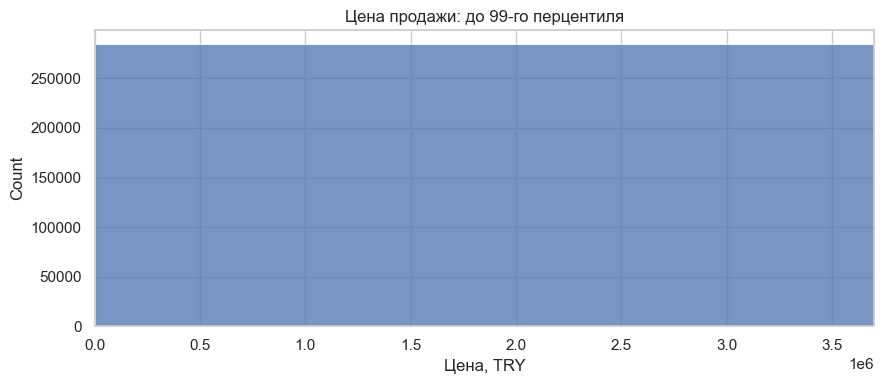

In [16]:
# Гистограмма с ограничением оси до 99-го перцентиля для читаемости.
plt.figure(figsize=(9,4))
sns.histplot(sale.price, bins=80)
plt.xlim(0,sale.price.quantile(.99)); plt.xlabel("Цена, TRY")
plt.title("Цена продажи: до 99-го перцентиля")
plt.tight_layout(); plt.show()

большинство объявлений сосредоточено на низких и средних ценах; справа остаётся длинный хвост. Ограничение оси скрывает только отображение верхнего 1%, данные не удалены.

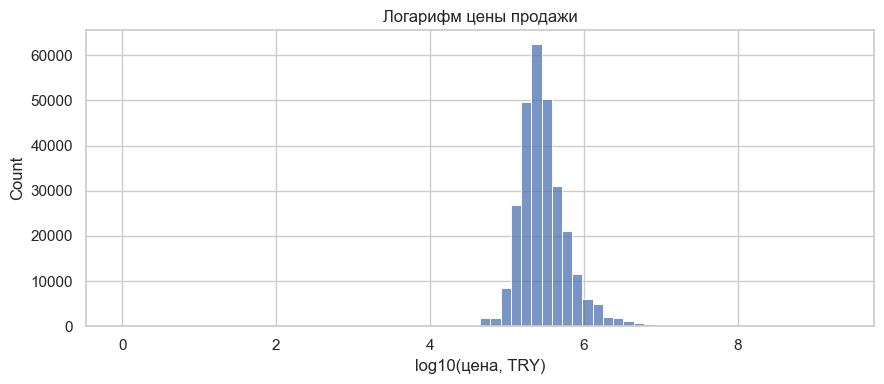

In [17]:
# Логарифмическая шкала раскрывает форму основного распределения.
plt.figure(figsize=(9,4))
sns.histplot(sale.log_price,bins=70)
plt.xlabel("log10(цена, TRY)"); plt.title("Логарифм цены продажи")
plt.tight_layout(); plt.show()

после преобразования основная масса цен видна лучше. Это аргумент проверить логарифмирование целевой переменной при моделировании, но качество нужно оценивать в исходных TRY.

## 1.3. Визуальный анализ

Пять типов визуализации: гистограммы, диаграммы рассеяния, boxplot, тепловая карта и столбчатые диаграммы. Каждый график отвечает на один вопрос. Для читаемости некоторые оси ограничены, а scatter использует фиксированную подвыборку; исходные данные от этого не меняются.

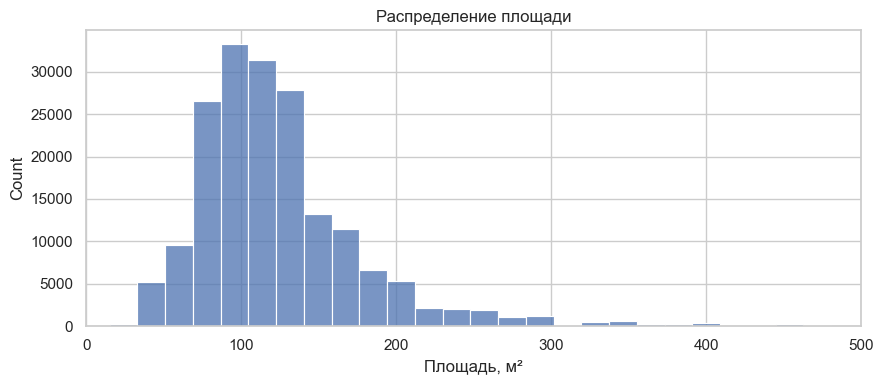

In [18]:
# Площадь: показываем правдоподобные записанные значения, без пропусков.
plt.figure(figsize=(9,4))
sns.histplot(sale.size_valid.dropna(),bins=55)
plt.xlim(0,500); plt.xlabel("Площадь, м²"); plt.title("Распределение площади")
plt.tight_layout(); plt.show()

основная масса объявлений описывает объекты примерно среднего размера; медиана среди допустимых записей — 115 м². Длинный правый хвост означает, что большие дома и здания нужно анализировать с учётом типа жилья.

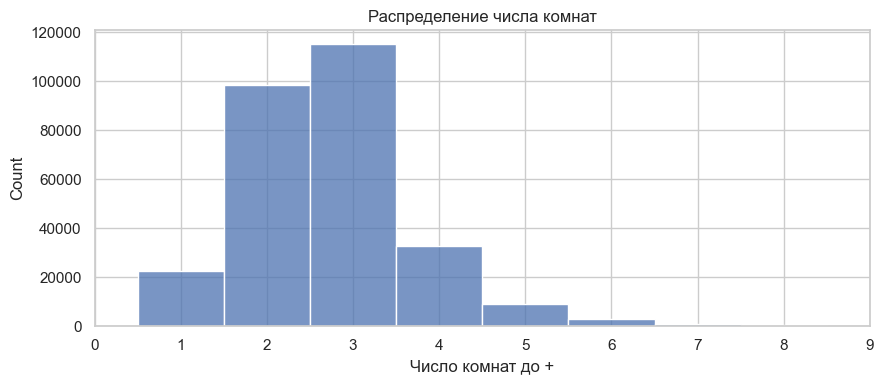

In [19]:
# Количество комнат: число до знака «+».
plt.figure(figsize=(9,4))
sns.histplot(sale.rooms.dropna(),discrete=True)
plt.xlim(0,9); plt.xlabel("Число комнат до +"); plt.title("Распределение числа комнат")
plt.tight_layout(); plt.show()

наиболее типичны 2–3 комнаты. Значение вроде `3+1` здесь превращено в 3; гостиная отдельно не учитывается. Записи вида `+` становятся пропусками.

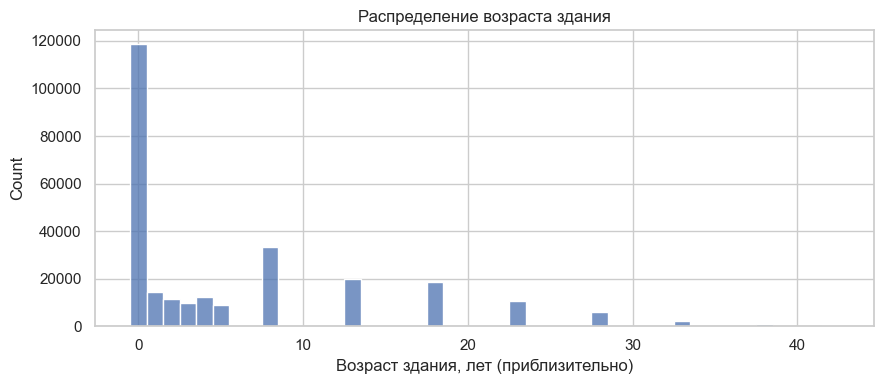

In [20]:
# Интервалы возраста заменены серединами для ориентировочного графика.
plt.figure(figsize=(9,4))
sns.histplot(sale.age_approx.dropna(),discrete=True)
plt.xlabel("Возраст здания, лет (приблизительно)")
plt.title("Распределение возраста здания")
plt.tight_layout(); plt.show()

много объявлений с возрастом 0 лет. Пики на 8, 13, 18 и других значениях частично созданы заменой диапазонов их серединами; это не точные годы постройки.

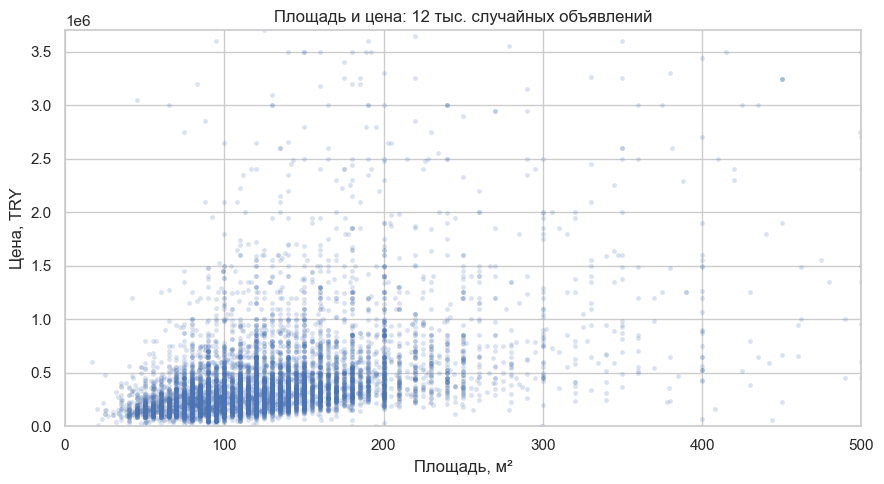

In [21]:
# Случайная подвыборка фиксирована, чтобы рисунок был воспроизводим.
sample = sale.loc[sale.size_valid.notna()].sample(n=min(12000,sale.size_valid.notna().sum()),random_state=RANDOM_STATE)
plt.figure(figsize=(9,5))
sns.scatterplot(data=sample,x="size_valid",y="price",alpha=.2,s=12,linewidth=0)
plt.xlim(0,500); plt.ylim(0,sale.price.quantile(.99))
plt.xlabel("Площадь, м²"); plt.ylabel("Цена, TRY")
plt.title("Площадь и цена: 12 тыс. случайных объявлений")
plt.tight_layout(); plt.show()

в целом более просторное жильё дороже, но при одной площади цены сильно различаются. Значит, одной площади для прогноза недостаточно — важны локация, тип объекта и другие характеристики.

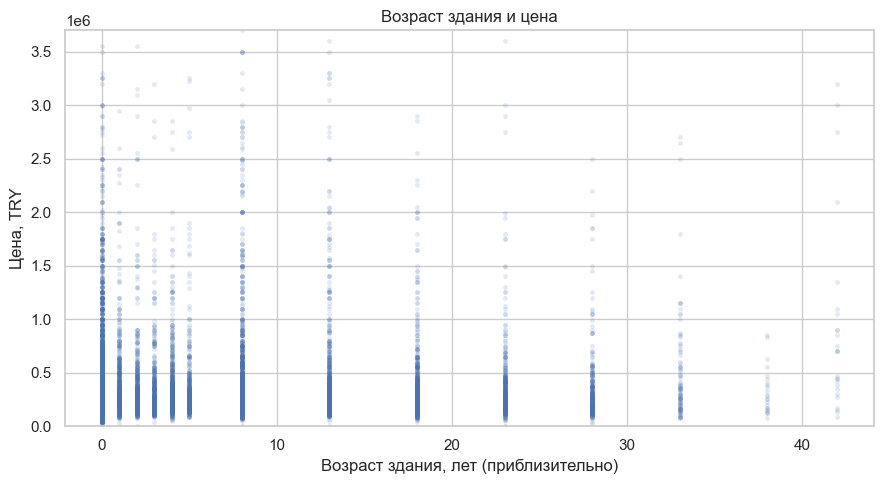

In [22]:
# Проверяем, видна ли прямая связь возраста здания с ценой.
age_sample = sale.loc[sale.age_approx.notna()].sample(n=min(12000,sale.age_approx.notna().sum()),random_state=RANDOM_STATE)
plt.figure(figsize=(9,5))
sns.scatterplot(data=age_sample,x="age_approx",y="price",alpha=.15,s=12,linewidth=0)
plt.ylim(0,sale.price.quantile(.99))
plt.xlabel("Возраст здания, лет (приблизительно)"); plt.ylabel("Цена, TRY")
plt.title("Возраст здания и цена")
plt.tight_layout(); plt.show()

явной прямой зависимости на общей выборке не видно. Возраст может влиять по-разному в разных городах и типах жилья; проверим это при моделировании.

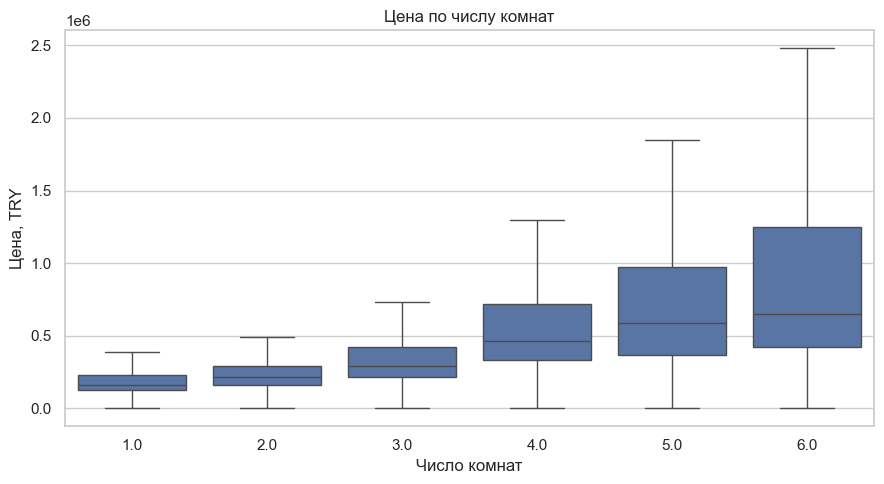

In [23]:
# Boxplot показывает медиану, квартили и разброс цен по комнатам.
limited = sale.loc[sale.price.le(sale.price.quantile(.99)) & sale.rooms.between(1,6)]
plt.figure(figsize=(9,5))
sns.boxplot(data=limited,x="rooms",y="price",showfliers=False)
plt.xlabel("Число комнат"); plt.ylabel("Цена, TRY")
plt.title("Цена по числу комнат")
plt.tight_layout(); plt.show()

медиана цены обычно растёт с числом комнат, но диапазоны разных групп сильно перекрываются. Число комнат полезно, однако само по себе не определяет цену. Точки выбросов скрыты для читаемости, строки сохранены.

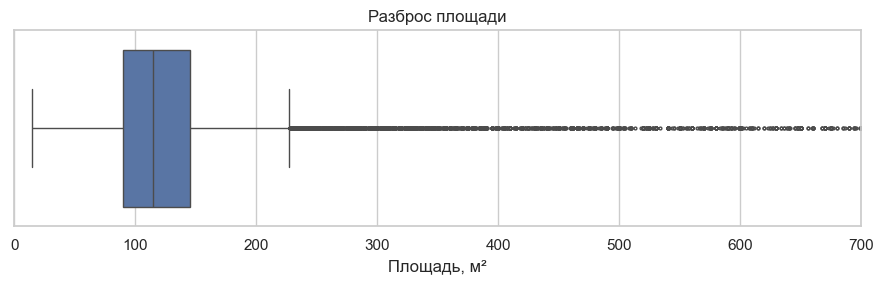

In [24]:
# Boxplot площади показывает потенциальные выбросы по правилу 1,5×IQR.
plt.figure(figsize=(9,3))
sns.boxplot(x=sale.size_valid.dropna(),showfliers=True,flierprops={"markersize":2})
plt.xlim(0,700); plt.xlabel("Площадь, м²")
plt.title("Разброс площади")
plt.tight_layout(); plt.show()

выше верхнего «уса» есть крупные объекты. Часть может быть реальной (например, виллы), поэтому автоматически удалять их нельзя. Сначала нужно проверить тип жилья и достоверность площади.

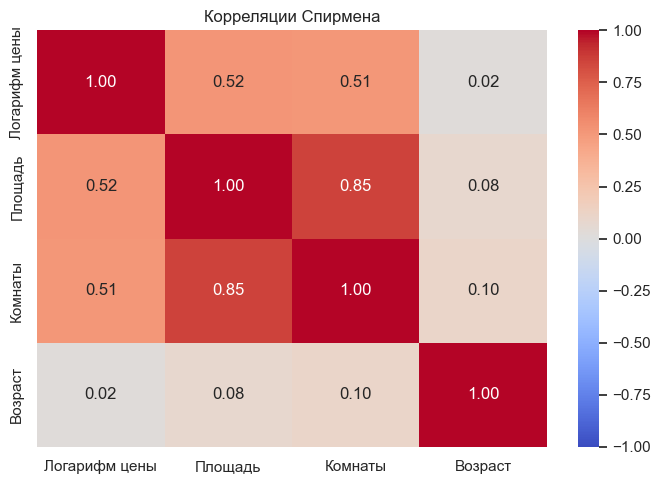

In [25]:
# Спирмен оценивает монотонную связь, не требуя нормальности цены.
corr = sale[["log_price","size_valid","rooms","age_approx"]].corr(method="spearman")
plt.figure(figsize=(7,5))
corr_ru=corr.rename(index={"log_price":"Логарифм цены","size_valid":"Площадь","rooms":"Комнаты","age_approx":"Возраст"},
                    columns={"log_price":"Логарифм цены","size_valid":"Площадь","rooms":"Комнаты","age_approx":"Возраст"})
sns.heatmap(corr_ru,annot=True,fmt=".2f",cmap="coolwarm",center=0,vmin=-1,vmax=1)
plt.title("Корреляции Спирмена")
plt.tight_layout(); plt.show()

цена связана с площадью (ρ≈0,52) и комнатами (ρ≈0,51). Площадь и комнаты сильно связаны между собой (ρ≈0,85), что важно для линейной регрессии. Общая корреляция возраста с ценой около 0,02 — почти нулевая.

In [26]:
# Таблица содержит точные коэффициенты для доклада.
show_table(corr_ru.round(3).rename_axis("Признак").reset_index())

Признак,Логарифм цены,Площадь,Комнаты,Возраст
Логарифм цены,1.00,0.52,0.51,0.02
Площадь,0.52,1.00,0.85,0.09
Комнаты,0.51,0.85,1.00,0.10
Возраст,0.02,0.09,0.10,1.00


округлённые значения на карте удобны для показа, а таблица даёт точность для отчёта. Корреляция показывает связь, но не доказывает причинность.

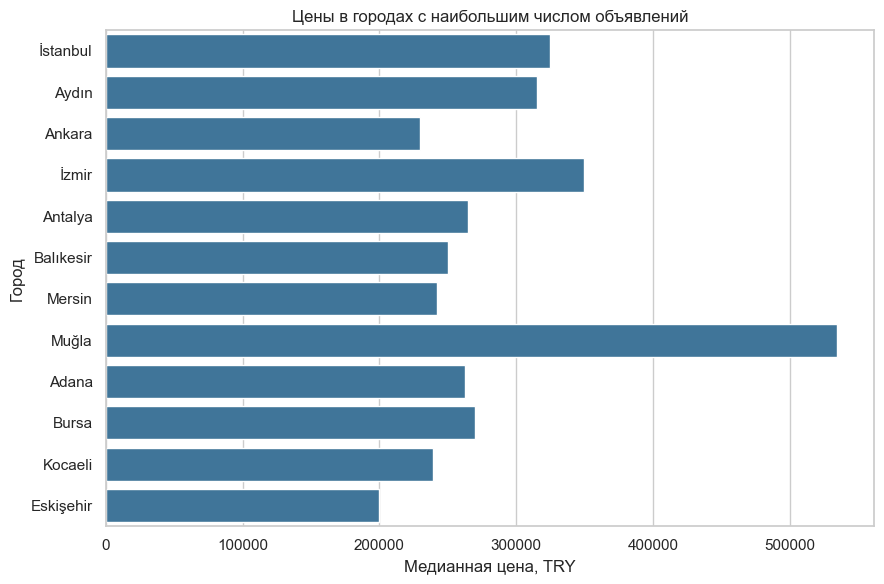

In [27]:
# Группы минимум с 500 объявлениями; медиана устойчива к редким дорогим объектам.
city_stats = sale.groupby("city").price.agg(["count","median","mean"]).query("count >= 500").sort_values("count",ascending=False).head(12)
plt.figure(figsize=(9,6))
sns.barplot(x=city_stats["median"],y=city_stats.index,color="#3178a8")
plt.xlabel("Медианная цена, TRY"); plt.ylabel("Город")
plt.title("Цены в городах с наибольшим числом объявлений")
plt.tight_layout(); plt.show()

медианная цена отличается: например, Мугла — 535 тыс. TRY, Анкара — 230 тыс. TRY. Местоположение должно входить в модель. Это сравнение не учитывает различия состава жилья между городами.

In [28]:
# Сопровождаем график числом записей и средними значениями.
show_table(city_stats.rename(columns={"count":"объявлений","median":"медиана, TRY","mean":"среднее, TRY"}).rename_axis("Город").reset_index())

Город,объявлений,"медиана, TRY","среднее, TRY"
İstanbul,70 697,325 000.00,803 107.93
Aydın,30 060,315 000.00,410 637.66
Ankara,24 898,230 000.00,317 963.66
İzmir,18 886,350 000.00,564 612.88
Antalya,17 242,265 000.00,401 930.20
Balıkesir,11 684,250 000.00,362 155.72
Mersin,8 873,242 000.00,542 719.42
Muğla,8 172,535 000.00,1 010 545.82
Adana,8 067,263 000.00,344 151.48
Bursa,7 671,270 000.00,374 855.02


в Стамбуле больше всего объявлений — 70 697. Среднее нередко выше медианы из-за дорогих объектов, поэтому для сравнения «типичного» жилья на графике использована медиана.

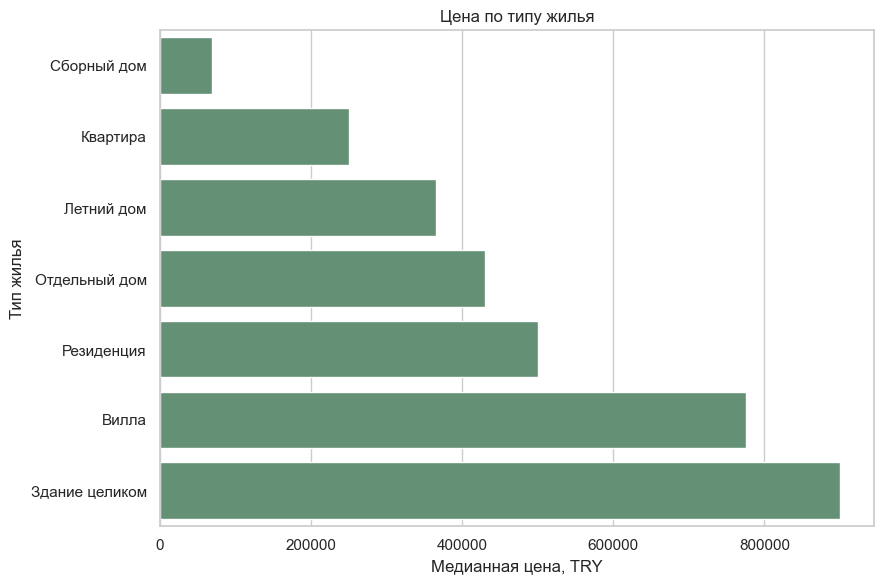

In [29]:
# Сравниваем типы жилья при достаточном числе записей.
type_stats = sale.groupby("sub_type").price.agg(["count","median","mean"]).query("count >= 500").sort_values("median")
plt.figure(figsize=(9,6))
sns.barplot(x=type_stats["median"],y=type_stats.index.map(lambda x: SUBTYPE_RU.get(x,x)),color="#5d9773")
plt.xlabel("Медианная цена, TRY"); plt.ylabel("Тип жилья")
plt.title("Цена по типу жилья")
plt.tight_layout(); plt.show()

медианная цена квартир — 250 тыс. TRY, вилл — 775 тыс. TRY. Тип объекта связан с ценой, но виллы обычно также больше по площади и находятся в других локациях.

In [30]:
# Таблица позволяет проверить размер групп и среднюю цену.
show_table(type_stats.rename(index=SUBTYPE_RU,columns={"count":"объявлений","median":"медиана, TRY","mean":"среднее, TRY"}).rename_axis("Тип жилья").reset_index())

Тип жилья,объявлений,"медиана, TRY","среднее, TRY"
Сборный дом,673,69 500.00,85 181.58
Квартира,244 914,250 000.00,354 780.81
Летний дом,5 741,365 000.00,428 952.07
Отдельный дом,7 899,430 000.00,753 782.61
Резиденция,4 249,500 000.00,1 319 870.16
Вилла,17 906,775 000.00,1 449 676.45
Здание целиком,2 209,900 000.00,2 672 778.00


квартиры составляют основную массу сегмента (244 914 записей), а другие группы гораздо меньше. Для редких типов оценки менее устойчивы; ниже порога 500 их нет на графике.

Наиболее явные кандидаты для модели — площадь, число комнат, локация и тип жилья. Возраст здания требует проверки вместе с другими признаками. Ни один отдельный график не заменяет оценку модели на отложенной выборке.

## 1.4. Пропуски и аномалии

Проверяем исходный датасет целиком. В этом разделе ничего не удаляем. Обработку пропусков и выбросов выполним на этапе 2 после разделения данных.

In [31]:
# Считаем пустые значения в каждом исходном столбце.
missing = pd.DataFrame({"пропусков":df[original_columns].isna().sum(),
                        "доля_%":df[original_columns].isna().mean().mul(100)}).sort_values("доля_%",ascending=False)
show_table(missing.rename(index=COLUMN_RU).round(2).rename_axis("Поле").reset_index())

Поле,пропусков,доля_%
Меблировка (furnished),403 487,100.00
"Площадь, м² (size)",146 006,36.19
Дата снятия (end_date),137 189,34.00
Этаж (floor_no),35 296,8.75
Этажей в здании (total_floor_count),28 021,6.94
Отопление (heating_type),27 970,6.93
Возраст здания (building_age),27 390,6.79
Валюта (price_currency),715,0.18
Цена (price),715,0.18
Номер (id),0,0.00


`furnished` пуст у всех 403 487 объектов. Площадь отсутствует у 146 006 (36,19%), `end_date` — у 137 189 (34%). Цены нет у 715 строк. Способ заполнения площади потребует проверки, потому что пропусков много.

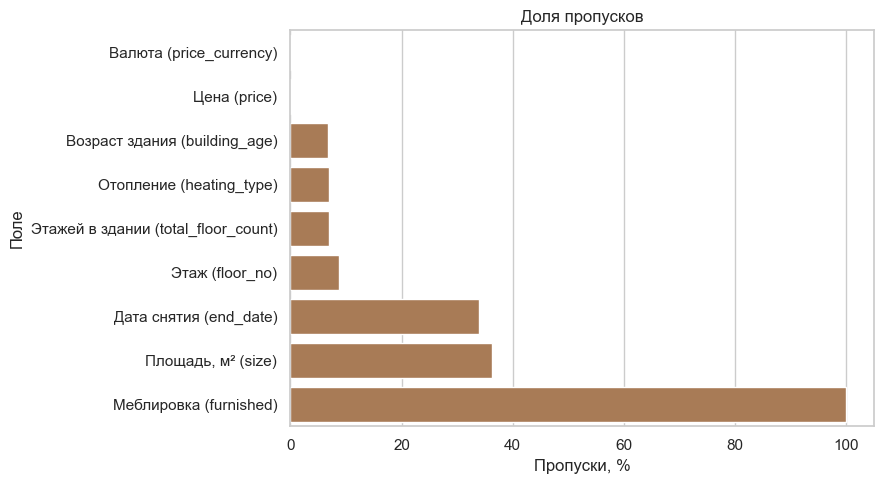

In [32]:
# График выделяет поля с ненулевой долей пропусков.
mplot = missing.loc[missing["доля_%"].gt(0)].sort_values("доля_%")
plt.figure(figsize=(9,5))
sns.barplot(x=mplot["доля_%"],y=mplot.index.map(lambda x: COLUMN_RU.get(x,x)),color="#b67a48")
plt.xlabel("Пропуски, %"); plt.ylabel("Поле"); plt.title("Доля пропусков")
plt.tight_layout(); plt.show()

главные проблемы — полностью пустой `furnished` и часто отсутствующая площадь. `end_date` может отсутствовать у активных объявлений; для прогноза на момент публикации это поле не нужно.

In [33]:
# Проверяем дубликаты, цену, площадь, даты, срок объявления и возраст.
end_dates = pd.to_datetime(df.end_date,format="%m/%d/%y",errors="coerce")
diagnostics = pd.Series({
    "дубликаты_строк":int(df[original_columns].duplicated().sum()),
    "повторные_id":int(df.id.duplicated().sum()),
    "цена_пустая":int(df.price.isna().sum()),
    "цена_неположительная":int(df.price.le(0).sum()),
    "площадь_неположительная":int(df["size"].le(0).sum()),
    "площадь_вне_15_1000":int((df["size"].notna() & ~df["size"].between(15,1000)).sum()),
    "дата_начала_некорректна":int(dates.isna().sum()),
    "дата_окончания_раньше_начала":int((end_dates<dates).sum()),
    "tom_отрицательный":int(df.tom.lt(0).sum()),
    "возраст_не_распознан_среди_заполненных":int((df.building_age.notna() & pd.to_numeric(df.building_age.replace(age_map),errors="coerce").isna()).sum())
})
show_table(diagnostics.to_frame("Количество").rename_axis("Проверка").reset_index())

Проверка,Количество
дубликаты_строк,0
повторные_id,0
цена_пустая,715
цена_неположительная,45
площадь_неположительная,0
площадь_вне_15_1000,1 140
дата_начала_некорректна,0
дата_окончания_раньше_начала,0
tom_отрицательный,0
возраст_не_распознан_среди_заполненных,0


полных дубликатов и повторных ID нет. Найдено 45 неположительных цен и 1 140 указанных площадей вне диагностического диапазона 15–1000 м². Большая площадь может принадлежать вилле или зданию, поэтому сам по себе размер не доказывает ошибку.

In [34]:
# IQR отмечает необычные значения, но не удаляет объекты.
iqr_rows = []
for col,label in [("price","Цена, TRY"),("size_valid","Площадь, м²")]:
    x = sale[col].dropna()
    q1,q3 = x.quantile([.25,.75])
    upper = q3 + 1.5*(q3-q1)
    iqr_rows.append({"признак":label,"Q1":q1,"Q3":q3,"верхняя_граница":upper,"выше_границы":int((x>upper).sum())})
show_table(pd.DataFrame(iqr_rows).rename(columns={"признак":"Признак","верхняя_граница":"Верхняя граница","выше_границы":"Выше границы"}))

Признак,Q1,Q3,Верхняя граница,Выше границы
"Цена, TRY",185 000.00,420 000.00,772 500.00,25 928
"Площадь, м²",90.00,145.00,227.50,10 234


выше статистической границы находятся примерно 25,9 тыс. цен и 10,2 тыс. площадей. Удалять все такие объекты нельзя: это заметно изменит выборку. На этапе 2 проверим их тип и локацию.

## 1.5. Промежуточные выводы и гипотезы

Эти гипотезы поддержаны EDA, но не доказывают причинную связь.

1. **Площадь связана с более высокой ценой.** Scatter и корреляция Спирмена ρ≈0,52; проверим связь внутри городов.
2. **Локация влияет на цену.** Медианы городов различаются: Мугла — 535 тыс. TRY, Анкара — 230 тыс. TRY.
3. **Тип жилья важен.** Медианы квартир и вилл — 250 и 775 тыс. TRY; проверим эффект после учёта площади и города.
4. **Число комнат полезно, но частично повторяет площадь.** Корреляция с ценой ρ≈0,51, с площадью ρ≈0,85.
5. **Возраст здания может влиять в отдельных сегментах.** Общая корреляция с ценой около 0,02, явного общего эффекта пока нет.

**Для следующего этапа:** разделить train/test до обучения импутеров и кодировщиков. Исключить `id`, `end_date`, `tom` и признаки, вычисленные из цены. Код `listing_type=1` уточнить по первоисточнику.

# Этап 2. Предварительная обработка данных

Сначала приводим цены к TRY. Затем проверяем сомнительные записи, разделяем данные и готовим признаки. Все решения по удалению записей показаны ниже; исходный CSV не меняется.

## Исходный набор

Источник — data/real_estate_data.csv. Целевая переменная — price (цена объявления). Площадь size измеряется в м².

In [ ]:
# Используем исходные столбцы набора, загруженного в этапе 1.
from sklearn.model_selection import GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor

ROOT = DATA_PATH.parent.parent.resolve()
raw = df[original_columns].copy()
print("Размер:", raw.shape)
display(raw.head(3))


В исходном наборе 403 487 строк. Сначала приводим цены к единой валюте, затем разбиваем объявления. Статистики заполнения и кодирования будем получать только из train.

### Приведение цены к одной валюте

Исторические курсы берём из [архива Центрального банка Турции](https://www.tcmb.gov.tr/kurlar/kurlar_en.html). Используется ForexBuying — TRY за единицу иностранной валюты. При отсутствии публикации за выходной берём последний курс до даты объявления (не старше 7 дней). Это справочный, а не фактический курс сделки. Время публикации объявления неизвестно, поэтому курс того же дня мог быть опубликован позже.

In [ ]:
# При первом запуске получаем курсы из TCMB и сохраняем локально.
from concurrent.futures import ThreadPoolExecutor
import requests
import xml.etree.ElementTree as ET

rate_file = ROOT / "data" / "external" / "tcmb_rates_2018-2019.csv"
if rate_file.exists():
    rates = pd.read_csv(rate_file)
    
else:
    dates = pd.to_datetime(raw.start_date, format="%m/%d/%y")
    def get_rate(day):
        url = f"https://www.tcmb.gov.tr/kurlar/{day:%Y%m}/{day:%d%m%Y}.xml"
        response = requests.get(url, timeout=20)
        if response.status_code == 404:
            return []
        response.raise_for_status()
        root = ET.fromstring(response.content)
        assert pd.to_datetime(root.attrib["Tarih"], format="%d.%m.%Y") == day
        return [{"rate_date": day, "currency": item.attrib["Kod"],
                 "try_per_unit": float(item.findtext("ForexBuying")) / float(item.findtext("Unit"))}
                for item in root.findall("Currency")
                if item.attrib.get("Kod") in ("EUR", "USD", "GBP")]
    with ThreadPoolExecutor(max_workers=10) as pool:
        daily = pool.map(get_rate, pd.date_range(dates.min()-pd.Timedelta(days=7), dates.max()))
        rates = pd.DataFrame(row for day in daily for row in day)
    rate_file.parent.mkdir(parents=True, exist_ok=True)
    rates.to_csv(rate_file, index=False)
rates["rate_date"] = pd.to_datetime(rates.rate_date)
assert set(rates.currency) == {"EUR", "USD", "GBP"}
assert rates.try_per_unit.gt(0).all()

print("Дней с опубликованными курсами:", rates.rate_date.nunique())
rates.head(10)

За нужный период в архиве 130 дней публикации курсов. Проверки подтверждают наличие EUR, USD и GBP и положительность курсов.

In [ ]:
# Оставляем код 1 с положительной ценой; иностранные цены умножаем на курс.
sale = raw.loc[raw.listing_type.eq(1) & raw.price.gt(0)].copy()
sale["original_currency"] = sale.price_currency
sale["listing_date"] = pd.to_datetime(sale.start_date, format="%m/%d/%y")
sale["rate_date"] = pd.NaT
sale["fx_rate"] = 1.0
for currency in ("EUR", "USD", "GBP"):
    part = sale.loc[sale.original_currency.eq(currency), ["listing_date"]]
    left = part.sort_values("listing_date").reset_index().rename(columns={"index":"row_id"})
    right = rates.loc[rates.currency.eq(currency), ["rate_date","try_per_unit"]].sort_values("rate_date")
    match = pd.merge_asof(left, right, left_on="listing_date", right_on="rate_date",
                          direction="backward", tolerance=pd.Timedelta(days=7))
    assert match.try_per_unit.notna().all(), f"Курс {currency} не найден"
    sale.loc[match.row_id.to_numpy(), "fx_rate"] = match.try_per_unit.to_numpy()
    sale.loc[match.row_id.to_numpy(), "rate_date"] = match.rate_date.to_numpy()
sale["price"] *= sale.fx_rate
sale["price_currency"] = "TRY"
foreign = sale.original_currency.ne("TRY")
lag = (sale.loc[foreign,"listing_date"]-sale.loc[foreign,"rate_date"]).dt.days
display(sale.groupby("original_currency").price.agg(["size","median"]))
print("Всего:",len(sale),"| пересчитано:",foreign.sum(),
      "| без курса:",sale.loc[foreign,"rate_date"].isna().sum(),
      "| максимальный разрыв:",lag.max(),"дня")
assert len(sale)==286392 and foreign.sum()==1924 and lag.between(0,7).all()

В итоге 286 392 объявления: 284 468 цен изначально в TRY и 1 924 пересчитаны из EUR, USD и GBP. Пропусков курса нет, максимальный разрыв с датой объявления — 3 дня. Типы 2 и 3 не добавляем: пересчёт валюты не превращает аренду или неизвестный платёж в продажу.

## 2.1. Пропуски, аномалии и разбиение

### Повторяющиеся карточки

Уникальный `id` не гарантирует, что остальные поля отличаются. Проверяем совпадения по всем исходным столбцам, кроме `id`, прежде чем делить объявления на части.


In [ ]:
# Считаем одинаковые карточки без учёта уникального ID.
compare_cols = [col for col in original_columns if col != "id"]
cards = raw.loc[sale.index, compare_cols]
repeated = cards.duplicated(keep=False)
extra_repeats = cards.duplicated().sum()
display(pd.DataFrame({
    "Показатель":["Строки в группах одинаковых карточек",
                  "Повторы сверх одной записи на группу"],
    "Объявлений":[int(repeated.sum()),int(extra_repeats)],
}))
display(sale.loc[repeated,
    ["id","address","sub_type","price","size","room_count","start_date"]]
    .sort_values(["address","sub_type","price"]).head(6))


По всем полям, кроме ID, совпадают **13 912 строк**; из них **8 114** — повторы сверх одной записи на группу. Без идентификатора физического объекта нельзя отличить повторно опубликованное объявление от нескольких одинаковых квартир одного проекта. Поэтому записи не удаляем по этому признаку. При групповом разбиении совпадающие карточки остаются в одной части и не создают пересечение train с validation/test.


In [ ]:
# Смотрим, где и сколько пропусков.
missing = pd.DataFrame({"Пропусков":sale.isna().sum(),
                        "Доля, %":sale.isna().mean()*100}).sort_values("Доля, %",ascending=False)
display(missing)
print("Полных дубликатов:", sale.duplicated().sum())

### Шаг 1. Разделение данных

Сначала создаём train, validation и test. Похожие объявления с одинаковыми адресом, типом, комнатами и площадью не должны оказаться в разных частях. Дальше пороги выбираем по train, не глядя на цены validation/test.

In [ ]:
# Разбиение по группам: примерно 70% / 15% / 15%.
groups = pd.util.hash_pandas_object(
    sale[["address","sub_type","room_count","size"]], index=False)
first = GroupShuffleSplit(n_splits=1, test_size=.15, random_state=42)
dev_idx,test_idx = next(first.split(sale, groups=groups))
dev = sale.iloc[dev_idx]
second = GroupShuffleSplit(n_splits=1, test_size=.15/.85, random_state=43)
train_idx,val_idx = next(second.split(dev, groups=groups.iloc[dev_idx]))
train,val,test = dev.iloc[train_idx],dev.iloc[val_idx],sale.iloc[test_idx]
display(pd.DataFrame({"Часть":["train","validation","test"],
                      "Объявлений":[len(train),len(val),len(test)]}))

### Шаг 2. Выбор порогов по train

Местные аналоги — объявления train того же адреса и типа жилья с ценой от 10 000 TRY. Слишком дешёвые цены не включаем в расчёт медианы, чтобы они её не искажали. Для сравнения требуются минимум два аналога. Если их меньше, отношение к медиане считаем неизвестным.

In [ ]:
# Сравнение нижней границы цены только на train.
peers = train.loc[train.price.ge(10_000)].groupby(
    ["address","sub_type"]).price.agg(peer_count="size", peer_median="median")
sale = sale.join(peers, on=["address","sub_type"])
sale["price_ratio"] = (sale.price / sale.peer_median).where(sale.peer_count.ge(2))
train_prices = sale.loc[train.index]

rows = []
for threshold in (1000,2000,5000,10000):
    mask = train_prices.price.lt(threshold)
    rows.append([threshold,int(mask.sum()),
                 int((mask & train_prices.peer_count.ge(2)).sum()),
                 int((mask & train_prices.price_ratio.lt(.01)).sum())])
display(pd.DataFrame(rows,columns=[
    "Порог, TRY","Ниже порога","Есть местные аналоги","Дешевле медианы >100 раз"]))

При границе 1 000 TRY мы исключили бы лишь 112 записей train. Граница **5 000 TRY** охватывает 207: у 190 есть местные аналоги, и 182 дешевле их медианы более чем в 100 раз. Граница 10 000 TRY добавляет ещё 21 запись, но только одно дополнительное сильное расхождение. Выбираем **5 000 TRY**.

In [ ]:
# Проверяем, насколько строгим должно быть сравнение с местной ценой.
rows = []
for share in (.005,.01,.02):
    mask = train_prices.price_ratio.lt(share)
    rows.append([f"{share:.1%}",int(mask.sum()),
                 int((mask & train_prices.price.ge(5000)).sum())])
display(pd.DataFrame(rows,columns=[
    "Доля местной медианы","Объявлений train","Дополнительно к порогу 5 000 TRY"]))

Граница **1% местной медианы** добавляет к правилу 5 000 TRY четыре записи train (семь во всём наборе). При 2% дополнений уже восемь, включая менее очевидные случаи. Выбираем 1% как осторожную проверку сильного расхождения; без двух объявлений train в группе её не применяем.

In [ ]:
# Проверяем границу для очень дорогих объявлений.
rows = []
for multiplier in (10,15,20,30):
    standard = train_prices.sub_type.isin(["Daire","Rezidans"])
    scope = (standard & train_prices.price.ge(1_000_000)) | train_prices.price.gt(50_000_000)
    mask = scope & train_prices.price_ratio.ge(multiplier)
    rows.append([multiplier,int(mask.sum())])
display(pd.DataFrame(rows,columns=["Во сколько раз выше местной медианы","Кандидатов train"]))

Для квартир и резиденций проверяем превышение местной медианы при цене от 1 млн TRY. Для вилл, особняков и зданий применяем это правило только при цене выше 50 млн TRY: такие объекты менее однородны. Порог **20 раз** на train отмечает 53 записи; порог 30 пропускает часть квартир с явно неправдоподобными сочетаниями цены, площади и комнат. Порог выбран по содержанию записей, без метрик validation/test.


### Шаг 3. Правило для каждой подозрительной записи

| Условие | Что делаем |
| --- | --- |
| Цена ниже 5 000 TRY | Исключаем как ненадёжную полную цену продажи. |
| Цена меньше 1% местной медианы при минимум двух объявлениях train | Исключаем: сильно отличается от сопоставимых объектов даже выше 5 000 TRY. |
| Квартира или резиденция от 1 млн TRY стоит минимум в 20 раз дороже местной медианы | Исключаем из основной учебной задачи как неподтверждённую целевую цену. |
| Вилла, особняк или здание дороже 50 млн TRY стоит минимум в 20 раз дороже местной медианы | Исключаем; для остальных уникальных объектов одного отношения цен недостаточно. |
| Большая цена без местных аналогов | Сохраняем с пометкой «недостаточно данных», не называя цену проверенной. |
| Неправдоподобная площадь или этаж выше этажности | Сохраняем объявление, проблемный признак превращаем в пропуск. |
| Комнаты записаны как «+» | Сохраняем объявление, число комнат оставляем неизвестным. |

Правила ограничивают область учебной модели. Статистическое отклонение само по себе не доказывает ошибку продавца.


In [ ]:
# Отмечаем условия и записываем решение по каждому ID.
area = pd.to_numeric(sale["size"], errors="coerce")
floor = pd.to_numeric(sale.floor_no, errors="coerce")
floors = pd.to_numeric(sale.total_floor_count, errors="coerce")
room_ok = sale.room_count.astype("string").str.fullmatch(r"\d+\+\d+").fillna(False)
low_absolute = sale.price.lt(5000)
low_relative = sale.price_ratio.lt(.01)
standard = sale.sub_type.isin(["Daire","Rezidans"])
high_scope = (standard & sale.price.ge(1_000_000)) | sale.price.gt(50_000_000)
relative_high_all = sale.price.ge(1_000_000) & sale.price_ratio.ge(20)
high_relative = high_scope & sale.price_ratio.ge(20)
bad_area = (area.lt(15) | area.gt(100_000) |
            (area.gt(3000) & sale.sub_type.isin(["Daire","Rezidans"])))
bad_floor = floor.gt(floors) & floors.notna()
flags = pd.DataFrame({
    "Цена < 5 000 TRY":low_absolute,
    "Цена < 1% местной медианы":low_relative,
    "Цена > 50 млн TRY":sale.price.gt(50_000_000),
    "Цена > 20 местных медиан":relative_high_all,
    "Неправдоподобная площадь":bad_area,
    "Этаж выше этажности":bad_floor,
    "Комнаты не разобраны":sale.room_count.notna() & ~room_ok,
},index=sale.index).fillna(False)
display(flags.sum().rename("Объявлений").to_frame())

audit = sale.loc[flags.any(axis=1),
    ["id","sub_type","price","size","room_count","floor_no",
     "total_floor_count","address","original_currency",
     "peer_count","peer_median","price_ratio"]].copy()
audit["Причины"] = flags.loc[audit.index].apply(
    lambda row:", ".join(row.index[row.to_numpy()]),axis=1)
bad_ids = set(sale.loc[low_absolute | low_relative | high_relative,"id"])
audit["Решение"] = np.where(audit.id.isin(bad_ids),"исключить","оставить")
audit["Исходная цена"] = raw.loc[audit.index,"price"]
audit["Проверка цены"] = np.where(audit.peer_count.ge(2),
    "есть ≥2 аналога train","аналогов train меньше 2")
audit["Исправление признаков"] = np.select(
    [bad_area.loc[audit.index] & bad_floor.loc[audit.index],
     bad_area.loc[audit.index],bad_floor.loc[audit.index]],
    ["площадь и этаж → пропуск","площадь → пропуск","этаж → пропуск"],
    default="без изменений")
display(audit.groupby("Решение").size().rename("Объявлений").to_frame())

Проверки пересекаются: одна запись может стоить мало и иметь неверную площадь. Поэтому количества в таблице выше не складываются. В реестре по каждому ID отдельно записаны **решение по цене** и **исправление признаков**. Всего отмечено 3 682 объявления: 381 исключено из-за ненадёжной цены, 3 301 остаётся после обработки признаков.


In [ ]:
# Несколько конкретных примеров для защиты правил.
print("Высокие цены относительно местных аналогов train:")
display(audit.loc[high_relative.loc[audit.index],
    ["id","sub_type","price","peer_count","peer_median",
     "price_ratio","size","address"]].sort_values("price_ratio",ascending=False).head(15))
print("Всего исключённых из-за высокой цены:",int(high_relative.sum()))
print("Цены от 5 000 TRY, но ниже 1% местной медианы:")
display(audit.loc[(low_relative & ~low_absolute).loc[audit.index],
    ["id","sub_type","price","peer_count","peer_median",
     "price_ratio","size","address"]].sort_values("price"))

Квартира № 13210 площадью 130 м² стоит 300 млн TRY при местной медиане около 520 тыс. TRY. Дополнительно отмечены квартиры дешевле 50 млн TRY, которые прежний абсолютный порог пропускал; полная таблица ID находится в реестре. Среди уникальных вилл и зданий большой разрыв без других подтверждений остаётся поводом для проверки, а не автоматического удаления.


In [ ]:
# Показываем, почему исправляем отдельные признаки.
print("Примеры неправдоподобной площади:")
display(sale.loc[bad_area,["id","sub_type","price","size","address"]]
        .sort_values("size",ascending=False).head(5))
print("Примеры этажа выше этажности здания:")
display(sale.loc[bad_floor,
    ["id","floor_no","total_floor_count","sub_type","address"]].head(5))

Площадь в сотни тысяч м² у квартиры не похожа на жилую площадь; этаж 4 при этажности здания 1 внутренне противоречив. Это свидетельства ошибки **признака**. Целевую цену таких объявлений мы не подменяем и строку не удаляем.

In [ ]:
# Фильтруем все три части по одинаковому правилу и проверяем группы.
train,val,test = [part.loc[~part.id.isin(bad_ids)].copy()
                  for part in (train,val,test)]
sale = sale.loc[~sale.id.isin(bad_ids)].copy()
parts = (train,val,test)
group_sets = [set(groups.loc[part.index]) for part in parts]
assert all(group_sets[i].isdisjoint(group_sets[j])
           for i,j in ((0,1),(0,2),(1,2)))
display(pd.DataFrame({
    "Часть":["train","validation","test"],
    "Объявлений":[len(part) for part in parts],
    "Доля, %":[100*len(part)/len(sale) for part in parts],
    "Медиана цены, TRY":[part.price.median() for part in parts],
}))

После отбора остаются объявления с ценой, пригодной для задачи полной стоимости продажи. Разбиение воспроизводимо, похожие объявления не пересекаются между частями. Validation и test далее используются только для оценки, а заполнители и кодировщики обучаются на train.

## 2.2. Выбросы

Цены оставленных объявлений не обрезаем. Ненадёжную площадь превращаем в пропуск и заполняем по train. Остальные очень большие площади ограничиваем по границам 0,1% и 99,9%, рассчитанным только на train.

In [ ]:
# Сравниваем обычное и логарифмическое распределение цены train.
fig,ax=plt.subplots(1,2,figsize=(12,4))
sns.histplot(train.price,bins=60,ax=ax[0])
ax[0].set(title="Цена",xlabel="TRY",xlim=(0,train.price.quantile(.99)))
sns.histplot(np.log1p(train.price),bins=60,ax=ax[1])
ax[1].set(title="Логарифм цены",xlabel="log(1+TRY)")
plt.tight_layout(); plt.show()
print("Асимметрия:",round(train.price.skew(),2))

Цена сильно скошена вправо: основная масса объявлений дешевле редких дорогих объектов. Логарифм помогает увидеть форму распределения, но целевую переменную для оценки оставляем в TRY.

## 2.3–2.4. Создание признаков

| Исходное поле | Что получаем | Зачем |
| --- | --- | --- |
| `address` | город, район, микрорайон | Цена зависит от расположения. |
| `room_count = 3+1` | 3 комнаты и 1 гостиная | Части записи имеют разный смысл. |
| `size` | площадь и флаг пропуска | Модель отличит реальную площадь от заполненной. |
| `building_age`, этажи | числовой возраст, этаж и признаки этажа | Учитываем положение и состояние здания. |
| `sub_type`, `heating_type` | категории | Позднее кодируем их на train. |

Цену за м² не создаём: она использует целевую цену и вызвала бы утечку. Расстояние до центра без координат не вычисляем.


In [ ]:
# Преобразования ниже не считают статистики и одинаковы для всех частей.
def features(part):
    x=pd.DataFrame(index=part.index)
    # Адрес: город, район, микрорайон.
    a=part.address.fillna("").str.split("/",n=2,expand=True)
    x["city"]=a[0].replace("",np.nan)
    x["district"]=(a[0]+"/"+a[1]).where(a[1].notna())
    x["neighborhood"]=(x["district"]+"/"+a[2]).where(a[2].notna() & a[2].ne(""))
    # Комнаты и площадь: неверная площадь становится пропуском.
    r=part.room_count.astype("string").str.extract(r"^(\d+)\+(\d+)$")
    x["bedrooms"]=pd.to_numeric(r[0],errors="coerce")
    x["living_rooms"]=pd.to_numeric(r[1],errors="coerce")
    x["rooms_missing"]=x["bedrooms"].isna().astype(int)
    x["size_m2"]=pd.to_numeric(part["size"],errors="coerce")
    valid_area=x.size_m2.ge(15) & x.size_m2.le(100_000)
    valid_area &= ~(x.size_m2.gt(3000) & part.sub_type.isin(["Daire","Rezidans"]))
    x["size_m2"]=x.size_m2.where(valid_area)
    x["size_missing"]=x.size_m2.isna().astype(int)
    # Возраст здания: интервалы заменяем серединами.
    age=part.building_age.astype("string")
    limits=age.str.extract(r"^(\d+)-(\d+) arası$").apply(pd.to_numeric,errors="coerce")
    x["building_age_years"]=pd.to_numeric(age,errors="coerce").fillna(limits.mean(axis=1)).fillna(age.map({"40 ve üzeri":40}))
    x["age_missing"]=x.building_age_years.isna().astype(int)
    x["is_new_building"]=x.building_age_years.eq(0).fillna(False).astype(int)
    # Этаж: конфликт проверяем только для точных числовых значений.
    floors=part.total_floor_count.astype("string")
    x["building_floors"]=pd.to_numeric(floors,errors="coerce").fillna(floors.map({"10-20 arası":15,"20 ve üzeri":20}))
    floor=part.floor_no.astype("string")
    x["floor_number"]=pd.to_numeric(floor,errors="coerce").fillna(floor.map({"Yüksek Giriş":1,"Giriş Katı":0,"Zemin Kat":0,"Bahçe katı":0,"20 ve üzeri":20}))
    basement=pd.to_numeric(floor.str.extract(r"^Kot (\d+)$")[0],errors="coerce")
    x["floor_number"]=x.floor_number.fillna(-basement)
    exact_floor=pd.to_numeric(floor,errors="coerce")
    exact_building=pd.to_numeric(floors,errors="coerce")
    x["floor_conflict"]=(exact_floor.gt(exact_building) & exact_building.notna()).fillna(False).astype(int)
    x.loc[x.floor_conflict.eq(1),"floor_number"]=np.nan
    x["floor_ratio"]=x.floor_number/x.building_floors.where(x.building_floors.gt(0))
    x["is_top_floor"]=(x.floor_number.eq(x.building_floors)&x.building_floors.notna()).fillna(False).astype(int)
    # Номинальные категории кодируются позднее на train.
    x["sub_type"]=part.sub_type
    x["heating_type"]=part.heating_type
    return x
X_train,X_val,X_test=[features(part) for part in parts]
y_train,y_val,y_test=[part.price.copy() for part in parts]
display(X_train.head(3))
print("Доля строк с микрорайоном в train, %:",round(100*X_train.neighborhood.notna().mean(),2))
print("Уникальных полных микрорайонов в train:",X_train.neighborhood.nunique())
print("Строк с неразобранными комнатами:",X_train.rooms_missing.sum())

Адрес разобран до микрорайона. Неизвестные комнаты, площадь и противоречивый этаж остаются пропусками, а не превращаются в ноль. Модель не получает цену, курс, ID и дату снятия объявления как признаки.

In [ ]:
# Медианы площади получаем только по train.
by_neighborhood=X_train.groupby(["neighborhood","sub_type"]).size_m2.agg(["median","count"])
by_neighborhood=by_neighborhood.loc[by_neighborhood["count"].ge(20),"median"]
by_district=X_train.groupby(["district","sub_type"]).size_m2.agg(["median","count"])
by_district=by_district.loc[by_district["count"].ge(20),"median"]
by_type=X_train.groupby("sub_type").size_m2.median()
overall=X_train.size_m2.median()
def fill_area(x):
    result=x.copy()
    for keys,medians in [(["neighborhood","sub_type"],by_neighborhood),
                         (["district","sub_type"],by_district)]:
        index=pd.MultiIndex.from_frame(result[keys])
        local=pd.Series(medians.reindex(index).to_numpy(),index=result.index)
        result["size_m2"]=result.size_m2.fillna(local)
    result["size_m2"]=result.size_m2.fillna(result.sub_type.map(by_type)).fillna(overall)
    return result
before=[x.size_m2.isna().sum() for x in (X_train,X_val,X_test)]
X_train,X_val,X_test=[fill_area(x) for x in (X_train,X_val,X_test)]
display(pd.DataFrame({"Часть":["train","validation","test"],
                      "Пропусков площади до":before,
                      "После":[x.size_m2.isna().sum() for x in (X_train,X_val,X_test)]}))
print("Групп микрорайон+тип с ≥20 известными площадями:",len(by_neighborhood))
print("Общая медиана train:",overall)


Все пропуски площади заполнены без удаления строк. Если данных достаточно, медиана учитывает микрорайон и тип жилья; для малых групп предусмотрены район, тип и общая медиана. Все уровни вычислены только по train.

In [ ]:
# Пороги площади также получаем только из train.
low,high=X_train.size_m2.quantile([.001,.999])
for x in (X_train,X_val,X_test):
    x["size_m2"]=x.size_m2.clip(low,high)
print("Границы площади, м²:",round(low,1),"—",round(high,1))

Площадь ограничена одинаково во всех трёх частях. Строки не удалены, целевая цена не изменена.

## 2.5. Кодирование и масштабирование

Город, район, микрорайон, тип жилья и отопление — номинальные категории, поэтому применяем One-Hot Encoding. Редкие категории объединяем. Для линейной модели числа стандартизируем; для деревьев оставляем без масштабирования.

In [ ]:
# Все заполнители, кодировщик и скалер обучаются только на train.
num=["size_m2","bedrooms","living_rooms","building_age_years","building_floors",
     "floor_number","floor_ratio","floor_conflict","size_missing","rooms_missing","age_missing","is_new_building","is_top_floor"]
cat=["city","district","neighborhood","sub_type","heating_type"]
def build_encoder(scale):
    steps=[("missing",SimpleImputer(strategy="median"))]
    if scale: steps.append(("scale",StandardScaler()))
    return ColumnTransformer([
        ("num",Pipeline(steps),num),
        ("cat",Pipeline([("missing",SimpleImputer(strategy="most_frequent")),
                         ("onehot",OneHotEncoder(handle_unknown="infrequent_if_exist",
                                                 min_frequency=100))]),cat)
    ],sparse_threshold=.3)
linear_preprocessor=build_encoder(True)
tree_preprocessor=build_encoder(False)
X_train_linear=linear_preprocessor.fit_transform(X_train)
X_val_linear=linear_preprocessor.transform(X_val)
X_test_linear=linear_preprocessor.transform(X_test)
X_train_tree=tree_preprocessor.fit_transform(X_train)
X_val_tree=tree_preprocessor.transform(X_val)
X_test_tree=tree_preprocessor.transform(X_test)
display(pd.DataFrame({"Часть":["train","validation","test"],
                      "Строк":[x.shape[0] for x in (X_train_linear,X_val_linear,X_test_linear)],
                      "Признаков":[x.shape[1] for x in (X_train_linear,X_val_linear,X_test_linear)]}))

Число столбцов совпадает во всех частях: новые категории не ломают обработку. Важное правило для следующего этапа: при кросс-валидации кодировщик и заполнители должны обучаться внутри каждого тренировочного фолда.

## 2.6. Проверка результата

Проверяем конечность значений и мультиколлинеарность основных числовых признаков с помощью VIF. Новые признаки сами по себе не гарантируют отсутствие корреляции.

In [ ]:
from scipy import sparse
for matrix in (X_train_linear,X_val_linear,X_test_linear,X_train_tree,X_val_tree,X_test_tree):
    values=matrix.data if sparse.issparse(matrix) else np.asarray(matrix)
    assert np.isfinite(values).all()
vif_cols=["size_m2","bedrooms","living_rooms","building_age_years",
          "building_floors","floor_number","floor_ratio"]
vif_data=pd.DataFrame(SimpleImputer(strategy="median").fit_transform(X_train[vif_cols]),
                      columns=vif_cols).sample(n=min(20000,len(X_train)),random_state=42)
vif_matrix=np.column_stack([np.ones(len(vif_data)),vif_data.to_numpy()])
vif=pd.DataFrame({"Признак":vif_cols,
                  "VIF":[variance_inflation_factor(vif_matrix,i+1) for i in range(len(vif_cols))]})
display(vif.sort_values("VIF",ascending=False))
print("Максимальный VIF:",round(vif.VIF.max(),2))
assert set(X_train.columns).isdisjoint({"price","price_ratio","peer_median","id"})
print("NaN и бесконечностей в итоговых матрицах нет; целевая цена не входит в признаки")

Все итоговые матрицы конечны: пропусков и бесконечностей нет. Максимальный VIF основных числовых признаков — **4,62**; по этому показателю сильной мультиколлинеарности среди проверенных числовых признаков нет. VIF здесь не оценивает сотни one-hot-столбцов.


In [ ]:
# Сохраняем полный реестр решений и ID частей.
processed = ROOT / "data" / "processed"
processed.mkdir(parents=True, exist_ok=True)
audit_path = processed / "anomaly_audit_main_v1.4.csv"
audit.to_csv(audit_path, index=False, encoding="utf-8-sig")
split_ids = pd.concat([
    pd.DataFrame({"id":train.id,"split":"train"}),
    pd.DataFrame({"id":val.id,"split":"validation"}),
    pd.DataFrame({"id":test.id,"split":"test"}),
]).sort_values("id")
split_path = processed / "split_ids_main_v1.4.csv"
assert audit.id.is_unique
assert split_ids.id.is_unique and len(split_ids) == len(sale)
assert not split_ids.id.isin(bad_ids).any()
split_ids.to_csv(split_path, index=False)
print("Реестр:", len(audit), "объявления →", audit_path)
print("Осталось для модели:", len(split_ids), "→", split_path)

## Итог этапа 2

Из 286 392 объявлений о предполагаемой продаже после проверки цены осталось **286 011**: train — **200 398**, validation — **42 657**, test — **42 956**. Исключены 308 записей с ненадёжной низкой ценой и 73 с сильным завышением относительно местных аналогов train. Ещё 3 301 подозрительное объявление сохранено; для 479 из них исправлена площадь, для 882 — этаж. Проверки могут пересекаться.

Признаки закодированы одинаково для всех частей: после one-hot получилось **718 столбцов**. В готовых матрицах нет пропусков и бесконечностей; максимальный VIF проверенных числовых признаков — **4,62**. Все медианы заполнения, границы площади, кодировщики и скалер обучены на train.

Полный реестр ID, причин и решений: `data/processed/anomaly_audit_main_v1.4.csv`. Воспроизводимое разбиение: `data/processed/split_ids_main_v1.4.csv`.

**Ограничение:** пороги задают область учебной модели, а не доказывают истинную рыночную цену каждой записи. Для 24 оставленных объявлений дороже 50 млн TRY местных аналогов train недостаточно. Метрики будущей модели относятся только к очищенному сегменту. Модели, обученные на прежних версиях данных, требуется переобучить.


## Этап 3. Построение модели регрессии

### 3.1. Базовое обучение 13 моделей

Сравниваем четыре линейные модели, дерево, случайный лес, четыре алгоритма бустинга и три дополнительных метода. Все модели получают одинаковые признаки и одни и те же строки train и validation. Преобразователи этапа 2 уже обучены только на train.

Для первой общей проверки берём случайные 8 000 строк train и 3 000 строк validation с фиксированным `random_state=42`. Это предварительное сравнение скорости и качества; метрики не являются итоговой оценкой на всём наборе. Test не используется.

In [1]:
# Базовые модели обучаются и проверяются на одинаковых строках.
import time, warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from scipy import sparse
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                             mean_absolute_percentage_error, r2_score,
                             median_absolute_error)
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

models = {
    "Linear Regression": LinearRegression(), "Ridge": Ridge(),
    "Lasso": Lasso(), "ElasticNet": ElasticNet(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42, n_jobs=4),
    "LightGBM": LGBMRegressor(random_state=42, verbosity=-1, n_jobs=4),
    "CatBoost": CatBoostRegressor(random_seed=42, verbose=False, thread_count=4, allow_writing_files=False),
    "KNN": KNeighborsRegressor(), "SVR": SVR(),
    "MLP": MLPRegressor(random_state=42),
}
assert len(models) == 13

# Фиксируем случайные выборки; test не используется.
rng = np.random.default_rng(42)
tr = np.sort(rng.choice(len(y_train), min(8000, len(y_train)), replace=False))
va = np.sort(rng.choice(len(y_val), min(3000, len(y_val)), replace=False))
X_small, y_small = X_train_linear[tr], y_train.iloc[tr].to_numpy()
X_check, y_check = X_val_linear[va], y_val.iloc[va].to_numpy()

def dense(matrix):
    return matrix.toarray() if sparse.issparse(matrix) else np.asarray(matrix)

results, fitted_models, predictions = [], {}, {}
for name, model in models.items():
    x_fit = dense(X_small).astype(np.float32, copy=False) if name == "CatBoost" else X_small
    x_val = dense(X_check).astype(np.float32, copy=False) if name == "CatBoost" else X_check
    start = time.perf_counter()
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always")
        model.fit(x_fit, y_small)
    seconds = time.perf_counter() - start
    pred = model.predict(x_val)
    predictions[name], fitted_models[name] = pred, model
    results.append({
        "Модель": name,
        "MAE, TRY": mean_absolute_error(y_check, pred),
        "RMSE, TRY": mean_squared_error(y_check, pred) ** .5,
        "MAPE, %": 100 * mean_absolute_percentage_error(y_check, pred),
        "R²": r2_score(y_check, pred),
        "Медианная ошибка, TRY": median_absolute_error(y_check, pred),
        "Обучение, сек": seconds,
        "Предупреждение": "Да" if caught else "Нет",
    })
    print(f"{name}: обучена за {seconds:.1f} сек", flush=True)

baseline_results = pd.DataFrame(results).sort_values("MAE, TRY").reset_index(drop=True)
metrics_path = ROOT / "data" / "processed" / "baseline_metrics_main_v1.5.csv"
baseline_results.to_csv(metrics_path, index=False, encoding="utf-8-sig")
display(baseline_results.round(2))
print(f"Общая выборка: train — {len(y_small):,}; validation — {len(y_check):,}; test не использовался.")
print("Таблица метрик сохранена:", metrics_path)

Linear Regression: обучена за 0.2 сек
Ridge: обучена за 0.1 сек
Lasso: обучена за 11.3 сек
ElasticNet: обучена за 0.2 сек
Decision Tree: обучена за 1.0 сек
Random Forest: обучена за 6.0 сек
Gradient Boosting: обучена за 1.5 сек
XGBoost: обучена за 0.5 сек
LightGBM: обучена за 0.1 сек
CatBoost: обучена за 7.2 сек
KNN: обучена за 0.0 сек
SVR: обучена за 4.9 сек
MLP: обучена за 22.7 сек
Общая выборка: train — 8,000; validation — 3,000; test не использовался.
Таблица метрик сохранена: C:\ForesightEstate\data\processed\baseline_metrics_main_v1.5.csv


C:\Users\2.0\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,Модель,"MAE, TRY","RMSE, TRY","MAPE, %",R²,"Медианная ошибка, TRY","Обучение, сек",Предупреждение
0,XGBoost,243006.24,1208425.69,40.08,0.34,61565.93,0.47,Нет
1,Random Forest,265985.60,1550575.28,38.89,-0.08,57693.20,5.96,Нет
2,CatBoost,268463.44,1385646.25,45.43,0.14,77455.40,7.18,Нет
3,Gradient Boosting,283882.38,1448023.32,53.45,0.06,84123.03,1.55,Нет
4,LightGBM,291204.36,1382397.69,49.17,0.14,68331.43,0.12,Нет
5,Decision Tree,296572.35,1471612.73,44.24,0.03,70000.00,0.98,Нет
6,KNN,316315.35,2047177.01,50.25,-0.89,73800.00,0.00,Нет
7,SVR,336002.76,1510885.80,52.13,-0.03,100511.58,4.90,Нет
8,ElasticNet,444690.15,1382170.30,125.96,0.14,265982.53,0.17,Нет
9,MLP,493572.33,1568165.95,89.28,-0.11,242429.50,22.74,Да


## Как читать метрики

**MAE** — средняя абсолютная ошибка в TRY; ниже — лучше. **RMSE** сильнее учитывает крупные промахи. **MAPE** показывает относительную ошибку в процентах, но чувствительна к дешёвым объектам. **R²** сравнивает модель с прогнозом среднего: 1 — идеально, 0 — не лучше среднего, ниже 0 — хуже среднего. Медианная ошибка показывает ошибку типичного объявления и меньше реагирует на крайние цены.

Сравнивайте прежде всего MAE вместе с R² и медианной ошибкой. Время обучения показывает, сколько ресурсов требует алгоритм.

<Figure size 1400x600 with 2 Axes>

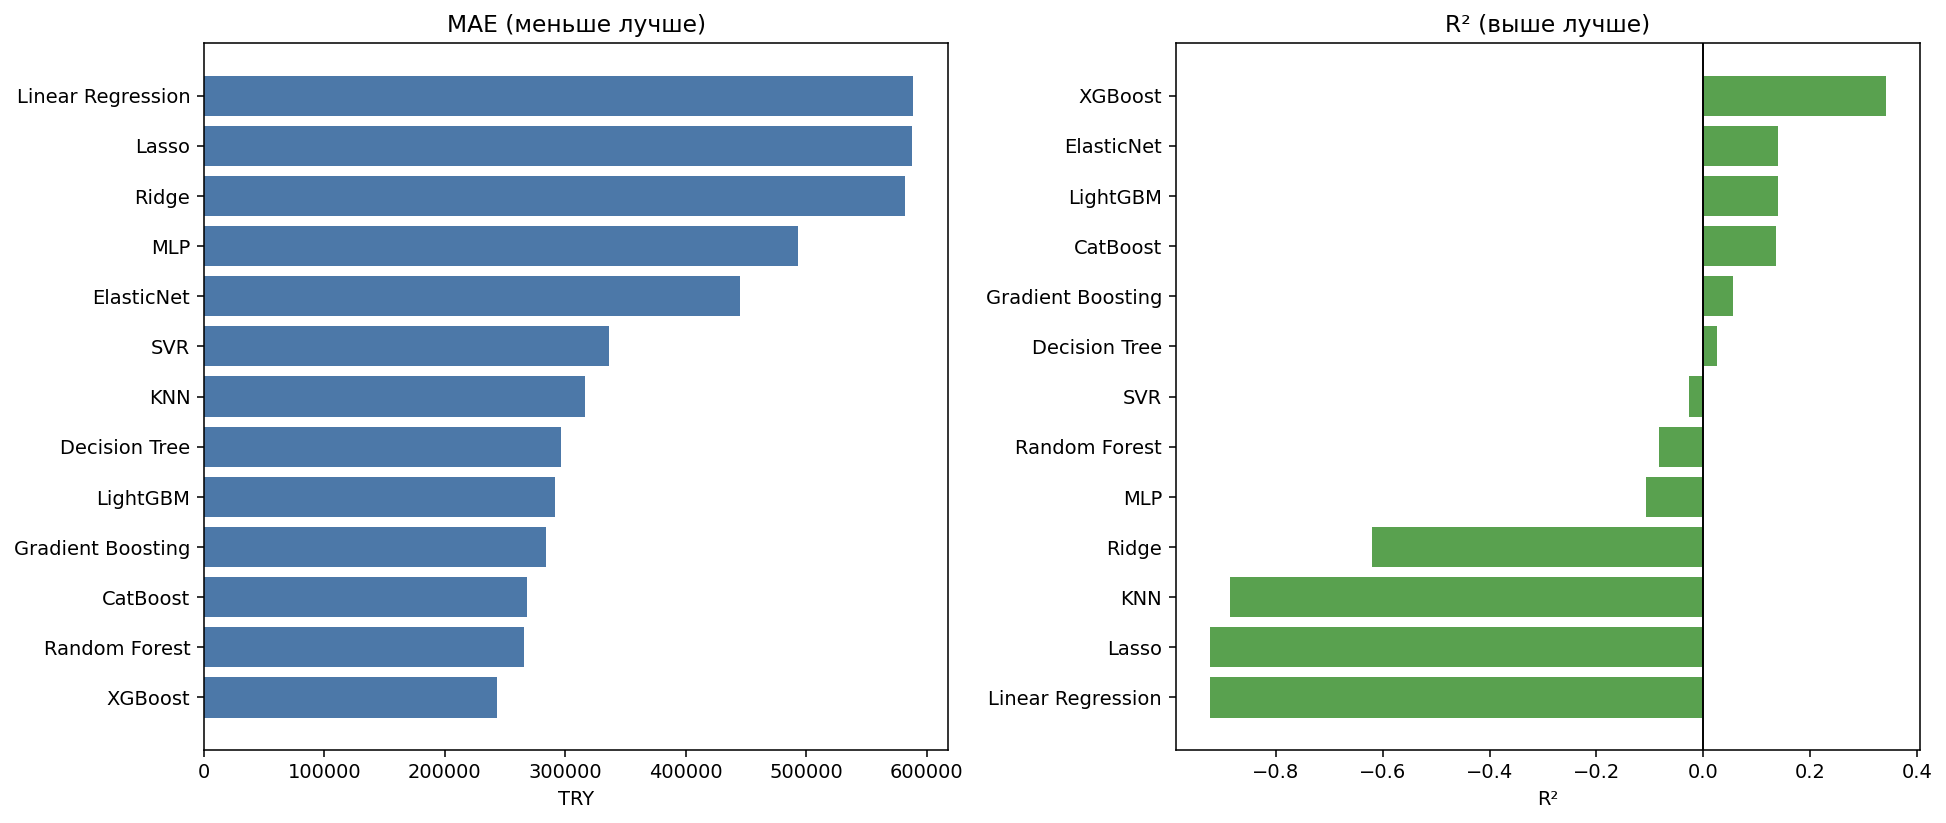

In [2]:
# Графики сравнивают MAE и R² на одной validation-выборке.
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
ordered = baseline_results.sort_values("MAE, TRY")
sns.barplot(data=ordered, x="MAE, TRY", y="Модель", color="#4C78A8", ax=axes[0])
axes[0].set(title="MAE (меньше лучше)", xlabel="TRY", ylabel="")
ordered_r2 = baseline_results.sort_values("R²")
sns.barplot(data=ordered_r2, x="R²", y="Модель", color="#59A14F", ax=axes[1])
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set(title="R² (выше лучше)", xlabel="R²", ylabel="")
plt.tight_layout(); display(fig)

In [3]:
# Фиксируем предварительного лидера по MAE.
best = baseline_results.iloc[0]
print(f"Лучшая базовая модель по MAE: {best['Модель']}.")
print(f"MAE = {best['MAE, TRY']:,.0f} TRY; медианная ошибка = {best['Медианная ошибка, TRY']:,.0f} TRY; R² = {best['R²']:.3f}.")
print("Это предварительный лидер: после настройки параметров и оценки на полной validation результат может измениться.")

Лучшая базовая модель по MAE: XGBoost.
MAE = 243,006 TRY; медианная ошибка = 61,566 TRY; R² = 0.343.
Это предварительный лидер: после настройки параметров и оценки на полной validation результат может измениться.


## Вывод по этапу 3.1 и выбор моделей

Для следующего сравнения оставляем три алгоритма разной природы:

| Модель | Семейство | Стартовые MAE / R² | Зачем оставляем |
|---|---|---:|---|
| Linear Regression | Линейная | 589 тыс. TRY / −0,924 | Простой обязательный ориентир. Отрицательный R² показывает, что линейной зависимости и базовых настроек недостаточно. |
| Decision Tree | Одиночное дерево | 297 тыс. TRY / 0,025 | Понятный нелинейный ориентир, который можно объяснить правилами дерева. |
| XGBoost | Бустинг | 243 тыс. TRY / 0,343 | Лучший стартовый результат по MAE среди 13 проверенных моделей. |

Две первые модели выбраны для сравнения разных подходов, а не потому, что они уже хорошо предсказывают цену. Базовые цифры получены на 8 000 строках train и 3 000 validation; дальше все три модели сравним на полном train и полной validation.

# 3.2. Подбор гиперпараметров

Сначала измеряем базовые Linear Regression, Decision Tree и XGBoost на полном train. Затем подбираем параметры с групповой трёхфолдо́вой кросс-валидацией на фиксированной подвыборке примерно 10% train, используя MAE как критерий. Подвыборка включает целые группы; после выбора параметров каждая модель переобучается на полном train. В один фолд не попадут объявления с одинаковыми адресом, типом жилья, комнатами и площадью.

В каждом CV-фолде заново обучаются заполнение площади, кодировщик категорий и масштабирование. Validation не участвует в подборе. Диапазон очистки объявлений уже зафиксирован этапом 2; метрики далее относятся к оставленному очищенному набору.

In [1]:
# В CV каждый преобразователь и модель обучаются заново только на части train.
import time, warnings, numpy as np, pandas as pd
from sklearn.base import clone, BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GroupKFold, GroupShuffleSplit, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                             mean_absolute_percentage_error, r2_score,
                             median_absolute_error)
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor

# Возвращает медианы площади, рассчитанные только на обучающей части каждого фолда.
class FoldAreaMedianImputer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        data = X[["neighborhood", "district", "sub_type", "size_m2"]].copy()
        data["size_m2"] = pd.to_numeric(data["size_m2"], errors="coerce")
        valid = data.dropna(subset=["size_m2"])
        nb = valid.groupby(["neighborhood", "sub_type"]).size_m2.agg(["median", "count"])
        ds = valid.groupby(["district", "sub_type"]).size_m2.agg(["median", "count"])
        self.nb_medians_ = nb.loc[nb["count"].ge(20), "median"]
        self.ds_medians_ = ds.loc[ds["count"].ge(20), "median"]
        self.type_medians_ = valid.groupby("sub_type").size_m2.median()
        self.overall_median_ = valid["size_m2"].median()
        self.area_low_, self.area_high_ = valid["size_m2"].quantile([.001, .999])
        return self

    def transform(self, X):
        data = X.copy()
        data["size_m2"] = pd.to_numeric(data["size_m2"], errors="coerce")
        for keys, medians in [
            (["neighborhood", "sub_type"], self.nb_medians_),
            (["district", "sub_type"], self.ds_medians_),
        ]:
            idx = pd.MultiIndex.from_frame(data[keys])
            local = pd.Series(medians.reindex(idx).to_numpy(), index=data.index)
            data["size_m2"] = data["size_m2"].fillna(local)
        data["size_m2"] = (
            data["size_m2"].fillna(data["sub_type"].map(self.type_medians_))
            .fillna(self.overall_median_)
            .clip(self.area_low_, self.area_high_)
        )
        return data

# Для моделирования берём исходные признаки до заполнения площади.
X_cv_train = features(train)
X_cv_val = features(val)
y_cv_train = train["price"].copy()
y_cv_val = val["price"].copy()

def model_pipeline(estimator, scale):
    return Pipeline([
        ("area_imputer", FoldAreaMedianImputer()),
        ("preprocessor", build_encoder(scale)),
        ("model", estimator),
    ])

model_specs = {
    "Linear Regression": {
        "estimator": LinearRegression(), "scale": True,
        "params": {"model__fit_intercept": [True, False]},
    },
    "Decision Tree": {
        "estimator": DecisionTreeRegressor(random_state=42), "scale": False,
        "params": {
            "model__max_depth": [None, 10, 20],
            "model__min_samples_leaf": [1, 10],
        },
    },
    "XGBoost": {
        "estimator": XGBRegressor(random_state=42, n_jobs=4), "scale": False,
        "params": {
            "model__n_estimators": [150, 300],
            "model__max_depth": [3, 5, 7],
            "model__learning_rate": [.03, .07, .12],
            "model__subsample": [.8, 1.0],
            "model__colsample_bytree": [.8, 1.0],
            "model__min_child_weight": [1, 5],
        },
    },
}
groups_cv = pd.util.hash_pandas_object(
    train[["address", "sub_type", "room_count", "size"]], index=False
)
cv = GroupKFold(n_splits=3)
# Для скорости берём около 10% train, но целые группы; затем лучший вариант переобучаем на всём train.
_, cv_positions = next(
    GroupShuffleSplit(n_splits=1, test_size=.10, random_state=42)
    .split(X_cv_train, groups=groups_cv)
)
X_cv_sample = X_cv_train.iloc[cv_positions]
y_cv_sample = y_cv_train.iloc[cv_positions]
groups_sample = groups_cv.iloc[cv_positions]
print(f"Подбор параметров: {len(y_cv_sample):,} train-строк, {groups_sample.nunique():,} групп; финальная подгонка — на всём train.")

def regression_metrics(y_true, pred):
    return {
        "MAE, TRY": mean_absolute_error(y_true, pred),
        "RMSE, TRY": mean_squared_error(y_true, pred) ** .5,
        "MAPE, %": 100 * mean_absolute_percentage_error(y_true, pred),
        "R²": r2_score(y_true, pred),
        "Медианная ошибка, TRY": median_absolute_error(y_true, pred),
    }

baseline_full, tuned_full, searches = [], [], {}
for name, spec in model_specs.items():
    # Базовая модель с настройками по умолчанию обучается на всём train.
    base = model_pipeline(clone(spec["estimator"]), spec["scale"])
    start = time.perf_counter()
    with warnings.catch_warnings(record=True):
        warnings.simplefilter("always")
        base.fit(X_cv_train, y_cv_train)
    base_seconds = time.perf_counter() - start
    base_pred = base.predict(X_cv_val)
    baseline_full.append({
        "Модель": name, "Вариант": "Базовая",
        **regression_metrics(y_cv_val, base_pred),
        "Время, сек": base_seconds,
    })

    # Линейную модель и дерево проверяем полной небольшой сеткой.
    if name != "XGBoost":
        search = GridSearchCV(
            model_pipeline(clone(spec["estimator"]), spec["scale"]),
            spec["params"], scoring="neg_mean_absolute_error",
            cv=cv, n_jobs=1, refit=False, error_score="raise",
        )
    # Для XGBoost случайно проверяем шесть комбинаций, чтобы ограничить время.
    else:
        search = RandomizedSearchCV(
            model_pipeline(clone(spec["estimator"]), spec["scale"]),
            spec["params"], n_iter=6, scoring="neg_mean_absolute_error",
            cv=cv, n_jobs=1, refit=False, random_state=42, error_score="raise",
        )
    start = time.perf_counter()
    with warnings.catch_warnings(record=True):
        warnings.simplefilter("always")
        search.fit(X_cv_sample, y_cv_sample, groups=groups_sample)
    search_seconds = time.perf_counter() - start
    # После выбора параметров обучаем финальный кандидат на всём train.
    tuned_model = model_pipeline(clone(spec["estimator"]), spec["scale"])
    tuned_model.set_params(**search.best_params_)
    start = time.perf_counter()
    tuned_model.fit(X_cv_train, y_cv_train)
    refit_seconds = time.perf_counter() - start
    tuned_pred = tuned_model.predict(X_cv_val)
    searches[name] = {"search": search, "model": tuned_model}
    tuned_full.append({
        "Модель": name, "Вариант": "После настройки",
        **regression_metrics(y_cv_val, tuned_pred),
        "CV MAE, TRY": -search.best_score_,
        "Лучшие параметры": str(search.best_params_),
        "Время CV, сек": search_seconds,
        "Обучение на полном train, сек": refit_seconds,
    })
    print(
        f"{name}: CV MAE { -search.best_score_:,.0f} TRY; "
        f"validation MAE {mean_absolute_error(y_cv_val, tuned_pred):,.0f} TRY",
        flush=True,
    )

baseline_full = pd.DataFrame(baseline_full)
tuned_full = pd.DataFrame(tuned_full)


Подбор параметров: 19,263 train-строк, 6,178 групп; финальная подгонка — на всём train.
Linear Regression: CV MAE 407,499 TRY; validation MAE 353,236 TRY
Decision Tree: CV MAE 281,552 TRY; validation MAE 241,692 TRY
XGBoost: CV MAE 253,787 TRY; validation MAE 229,007 TRY


## 3.3. Метрики на полной validation

Сравниваем базовую и настроенную версии на одних и тех же объектах полной validation. MAE, RMSE и медианная ошибка даны в TRY; MAPE — в процентах; R² без единиц. Параметры выбирались только по CV на train. Test не используем для выбора.

In [3]:
# Общая таблица: базовая и настроенная версии каждой модели на полной validation.
comparison_full = pd.concat([baseline_full, tuned_full], ignore_index=True, sort=False)
comparison_full = comparison_full.sort_values(["Модель", "Вариант"])
display(comparison_full.round(3))

# Сохраняем метрики и лучшие параметры для следующего этапа.
metrics_file = ROOT / "data" / "processed" / "model_tuning_main_v1.6.csv"
metrics_file.parent.mkdir(parents=True, exist_ok=True)
comparison_full.to_csv(metrics_file, index=False, encoding="utf-8-sig")
print("Таблица сохранена:", metrics_file)

Таблица сохранена: C:\ForesightEstate\data\processed\model_tuning_main_v1.6.csv


,Модель,Вариант,"MAE, TRY","RMSE, TRY","MAPE, %",R²,"Медианная ошибка, TRY","Время, сек","CV MAE, TRY",Лучшие параметры,"Время CV, сек","Обучение на полном train, сек"
1,Decision Tree,Базовая,258624.847,2330113.667,38.333,-0.195,56000.000,111.865,NaN,NaN,NaN,NaN
4,Decision Tree,После настройки,241692.414,1806029.417,42.346,0.282,68828.512,NaN,281552.077,"{'model__max_depth': 20, 'model__min_samples_l...",11.104,7.955
0,Linear Regression,Базовая,353203.435,1861668.678,89.567,0.237,152902.114,8.912,NaN,NaN,NaN,NaN
3,Linear Regression,После настройки,353235.545,1861658.304,89.584,0.237,152885.670,NaN,407499.285,{'model__fit_intercept': False},2.176,9.096
2,XGBoost,Базовая,217249.000,1651181.452,39.139,0.400,62063.422,4.354,NaN,NaN,NaN,NaN
5,XGBoost,После настройки,229007.471,1688767.744,44.578,0.372,72683.453,NaN,253786.893,"{'model__subsample': 1.0, 'model__n_estimators...",12.868,6.435


<Figure size 1300x500 with 2 Axes>

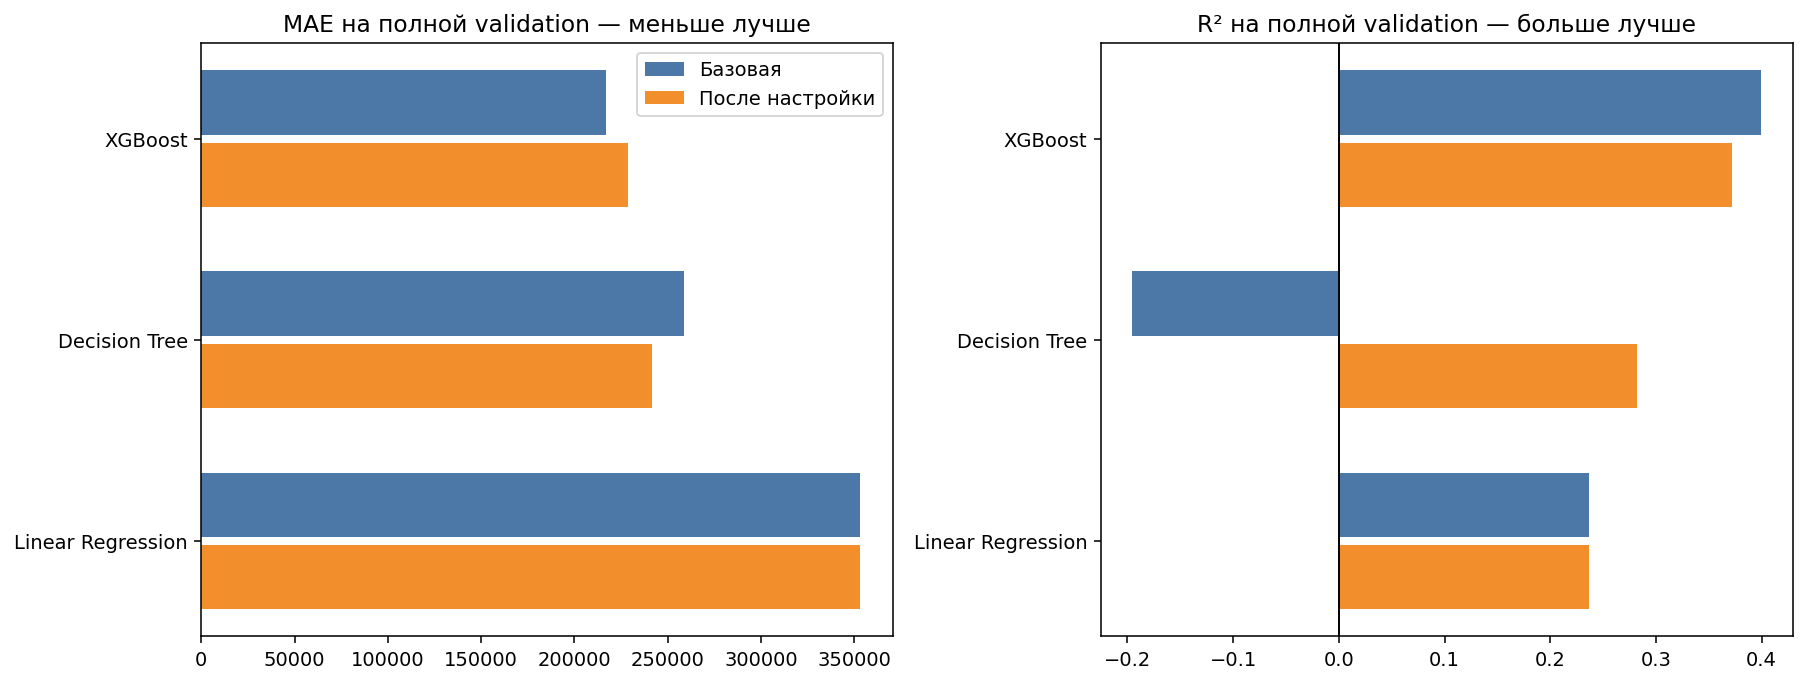

In [4]:
# Графики сравнивают базовую и настроенную модели по MAE и R².
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.barplot(data=comparison_full, x="MAE, TRY", y="Модель", hue="Вариант", ax=axes[0])
axes[0].set(title="MAE на полной validation (меньше лучше)", xlabel="TRY", ylabel="")
sns.barplot(data=comparison_full, x="R²", y="Модель", hue="Вариант", ax=axes[1])
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set(title="R² на полной validation (выше лучше)", xlabel="R²", ylabel="")
plt.tight_layout(); display(fig)

In [5]:
# Находим лучший результат среди базовых и настроенных моделей на полной validation.
best = comparison_full.sort_values("MAE, TRY").iloc[0]
xgb_base = comparison_full.query("Модель == 'XGBoost' and Вариант == 'Базовая'").iloc[0]
xgb_tuned = comparison_full.query("Модель == 'XGBoost' and Вариант == 'После настройки'").iloc[0]
tree_base = comparison_full.query("Модель == 'Decision Tree' and Вариант == 'Базовая'").iloc[0]
tree_tuned = comparison_full.query("Модель == 'Decision Tree' and Вариант == 'После настройки'").iloc[0]
print(f"Лучший результат среди шести вариантов: {best['Модель']} ({best['Вариант']}).")
print(f"MAE {best['MAE, TRY']:,.0f} TRY; RMSE {best['RMSE, TRY']:,.0f} TRY; "
      f"MAPE {best['MAPE, %']:.1f}%; R² {best['R²']:.3f}.")
print(f"XGBoost после настройки: MAE изменилось на {xgb_tuned['MAE, TRY']-xgb_base['MAE, TRY']:+,.0f} TRY, "
      f"R² {xgb_base['R²']:.3f} → {xgb_tuned['R²']:.3f}.")
print(f"Decision Tree после настройки: MAE изменилось на {tree_tuned['MAE, TRY']-tree_base['MAE, TRY']:+,.0f} TRY, "
      f"R² {tree_base['R²']:.3f} → {tree_tuned['R²']:.3f}.")
print("Validation использована для сравнения кандидатов; test в этом этапе не использовался.")

Лучший результат среди шести вариантов: XGBoost (Базовая).
MAE 217,249 TRY; RMSE 1,651,181 TRY; MAPE 39.1%; R² 0.400.
XGBoost после настройки: MAE изменилось на +11,758 TRY, R² 0.400 → 0.372.
Decision Tree после настройки: MAE изменилось на -16,932 TRY, R² -0.195 → 0.282.
Validation использована для сравнения кандидатов; test в этом этапе не использовался.

## Фактический результат этапов 3.2–3.3

Подбор параметров выполнен на **19 263 строках train, собранных в 6 178 целых группах**, с 3-fold GroupKFold. Лучшие параметры затем переобучены на полном train. Полная validation содержит те же объявления для сравнения всех шести вариантов.

| Модель | Базовая: MAE / R² | После настройки: MAE / R² |
|---|---:|---:|
| Linear Regression | 353,203 / 0.237 | 353,236 / 0.237 |
| Decision Tree | 258,625 / -0.195 | 241,692 / 0.282 |
| XGBoost | 217,249 / 0.400 | 229,007 / 0.372 |

На validation лучший из шести вариантов — **базовый XGBoost**: MAE 217,249; RMSE 1,651,181; MAPE 39.1%; R² 0.400; MedAE 62,063. Подобранный XGBoost дал MAE 229,007; RMSE 1,688,768; MAPE 44.6%; R² 0.372; MedAE 72,683: его MAE выросла примерно на 11 758 TRY, а R² снизился с 0,400 до 0,372. Значит, проведённый небольшой поиск не улучшил XGBoost.

Подбор помог одиночному дереву: MAE снизилась примерно на 16 932 TRY, а R² вырос с −0,195 до 0,282. Linear Regression почти не изменилась. Это наглядный результат подбора: он может и не улучшить модель, а качество сравниваем по validation, не по одному лишь значению CV.

**Важно:** метрики относятся к записям, оставшимся после правил этапа 2, включая проверку цен. Их нельзя автоматически трактовать как качество на всех исходных объявлениях. Test не применялся для обучения и выбора параметров; финальную оценку оставляем на следующий шаг.


## 3.4. Эксперимент: помогает ли убрать дорогие объявления?

Проверяем только XGBoost, чтобы сравнить именно влияние верхнего порога, а не смену алгоритма. Разбиение train/validation, признаки и настройки модели фиксированы. Пороги P75, P90, P95 и P99 считаются по цене train; из обучения исключаются значения выше границы. Validation не фильтруется: прогноз строится для всех её объектов.

Для интерпретации отдельно показываем метрики на полной validation, среднем диапазоне P10–P90 и дорогих объектах выше P90. Последние две строки — диагностические подгруппы по известной фактической цене, а не сегменты, которые можно заранее определить в приложении. Test не используется.

In [1]:
# Один алгоритм и одно разбиение; меняем только верхнюю границу цены в train.
import time
range_quantiles = y_cv_train.quantile([.10, .75, .90, .95, .99])
range_scenarios = [
    ("Весь train", None, None),
    ("До P99", None, .99),
    ("До P95", None, .95),
    ("До P90", None, .90),
    ("До P75", None, .75),
    ("Центр P10–P90", .10, .90),
]
scope_masks = [
    ("Вся validation", np.ones(len(y_cv_val), dtype=bool)),
    ("Средний сегмент P10–P90", y_cv_val.between(
        range_quantiles.loc[.10], range_quantiles.loc[.90]
    ).to_numpy()),
    ("Дороже P90", y_cv_val.gt(range_quantiles.loc[.90]).to_numpy()),
]
range_rows, range_predictions = [], {}
for label, lower_q, upper_q in range_scenarios:
    keep = pd.Series(True, index=y_cv_train.index)
    if lower_q is not None:
        keep &= y_cv_train.ge(range_quantiles.loc[lower_q])
    if upper_q is not None:
        keep &= y_cv_train.le(range_quantiles.loc[upper_q])
    x_fit, y_fit = X_cv_train.loc[keep], y_cv_train.loc[keep]

    model = model_pipeline(XGBRegressor(random_state=42, n_jobs=4), scale=False)
    start = time.perf_counter()
    model.fit(x_fit, y_fit)
    fit_seconds = time.perf_counter() - start
    pred = model.predict(X_cv_val)
    range_predictions[label] = pred

    for scope, mask in scope_masks:
        values = regression_metrics(y_cv_val.to_numpy()[mask], pred[mask])
        range_rows.append({
            "Диапазон train": label,
            "Строк train": len(y_fit),
            "Доля train, %": 100 * len(y_fit) / len(y_cv_train),
            "Оценка на": scope,
            "Строк validation": int(mask.sum()),
            **values,
            "Обучение, сек": fit_seconds,
        })

range_results = pd.DataFrame(range_rows)
print("Пороги train, TRY:")
display(range_quantiles.rename(index={
    .10: "P10", .75: "P75", .90: "P90", .95: "P95", .99: "P99"
}).round(0).to_frame("Цена"))
display(range_results[range_results["Оценка на"].eq("Вся validation")].round(2))
display(range_results[~range_results["Оценка на"].eq("Вся validation")].round(2))

# Сохраняем результаты, включая отдельную оценку дорогого сегмента.
range_file = ROOT / "data" / "processed" / "xgb_price_range_main_v1.7.csv"
range_file.parent.mkdir(parents=True, exist_ok=True)
range_results.to_csv(range_file, index=False, encoding="utf-8-sig")
print("Результаты сохранены:", range_file)

Результаты CSV: C:\ForesightEstate\data\processed\xgb_price_range_main_v1.7.csv
Диапазон train  Строк validation  MAE, TRY  RMSE, TRY  MAPE, %    R²  Медианная ошибка, TRY
    Весь train             34294  97583.82  299716.92    30.31 -3.46               55018.64
        До P99             34294  78962.16  124631.45    25.45  0.23               50365.92
        До P95             34294  66950.58   94189.48    22.16  0.56               46790.33
        До P90             34294  63303.55   88740.56    20.54  0.61               45173.17
        До P75             34294  77944.28  118901.01    21.25  0.30               45167.10
 Центр P10–P90             34294  63543.57   87796.77    21.24  0.62               45728.34
Средний сегмент P10–P90 на validation:
Диапазон train  Строк train  Доля train, %  MAE, TRY  RMSE, TRY  MAPE, %    R²  Медианная ошибка, TRY
    Весь train       200398         100.00 217249.00 1651181.45    39.14  0.40               62063.42
        До P99       198394      

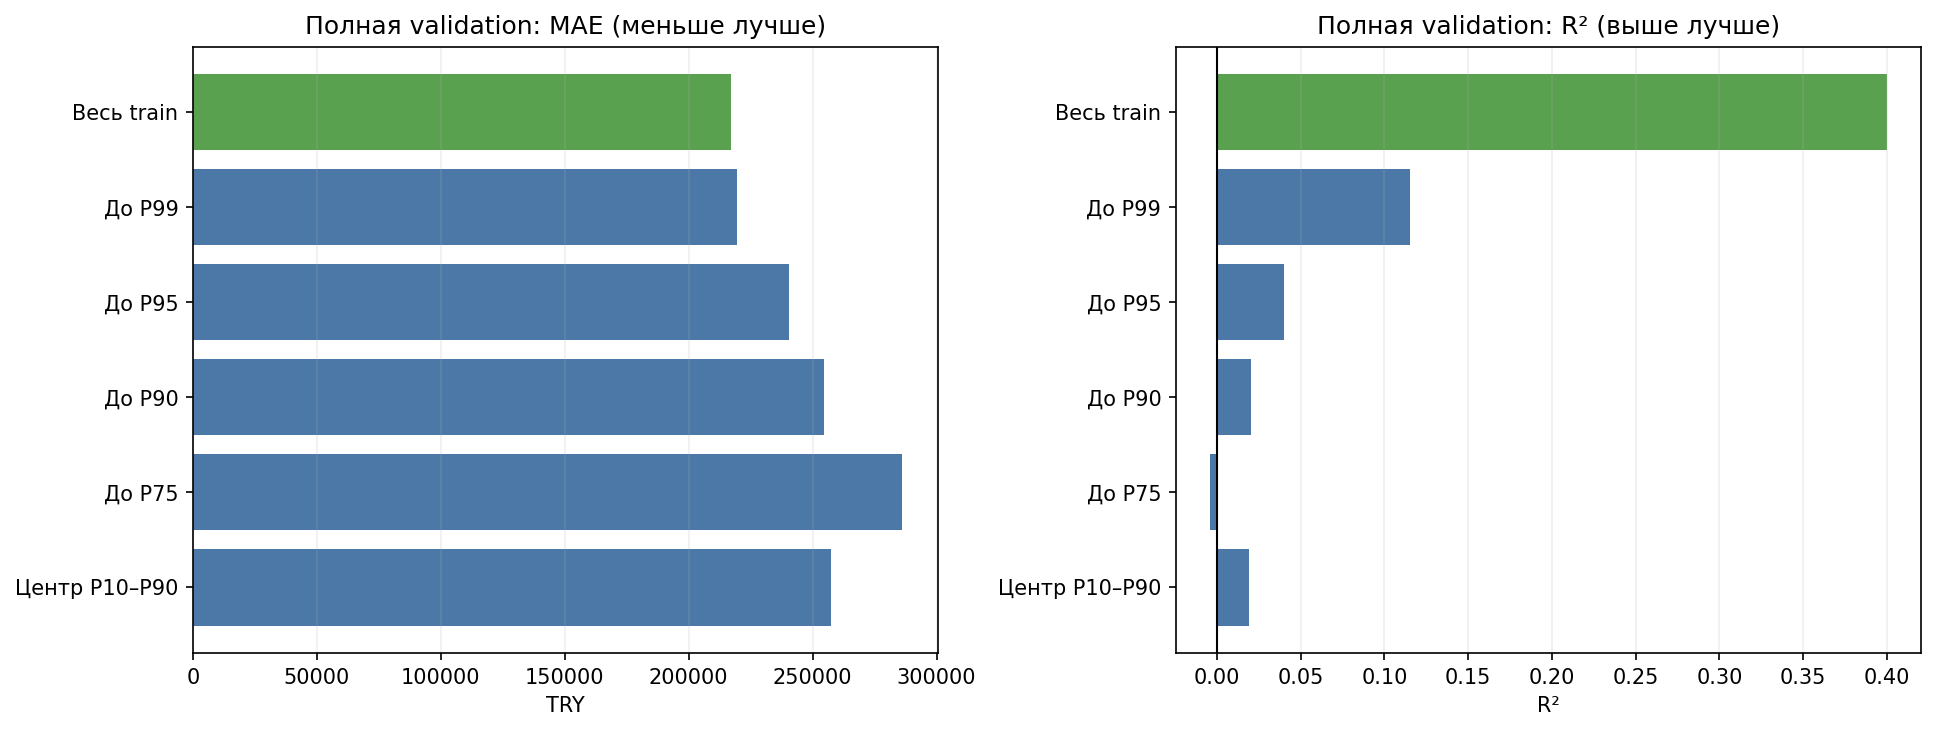

In [2]:
# Сравниваем MAE и R² на полной validation.
full_range = range_results[range_results["Оценка на"].eq("Вся validation")].copy()
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.barplot(data=full_range, x="MAE, TRY", y="Диапазон train", color="#4C78A8", ax=axes[0])
axes[0].set(title="Полная validation: MAE (меньше лучше)", xlabel="TRY", ylabel="")
sns.barplot(data=full_range, x="R²", y="Диапазон train", color="#59A14F", ax=axes[1])
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set(title="Полная validation: R² (выше лучше)", xlabel="R²", ylabel="")
plt.tight_layout(); display(fig)

### Итог эксперимента: стоит ли исключать дорогие объявления?

**Для модели, которая должна оценивать жильё любого ценового уровня, исключать дорогие объекты не стоит.** На полной validation модель, обученная на всём train, показала MAE **217 тыс. TRY** и R² **0,400**. После отсечения верхних 10% обучающих цен MAE выросла до **254 тыс. TRY**, а R² снизился до **0,020**. При отсечении верхних 25% MAE выросла до **286 тыс. TRY**, R² стал отрицательным (**−0,004**).

Есть и более узкий эффект: внутри среднего диапазона P10–P90 (по train это примерно **138–750 тыс. TRY**) отсечение верхнего хвоста улучшает точность. Например, при обучении без верхних 10% MAE на среднем сегменте снизилась с **97,6 тыс. до 63,3 тыс. TRY**, а R² вырос с **−3,46 до 0,61**. Но на дорогих объявлениях MAE при этом выросла с **1,34 млн до 2,04 млн TRY**, а R² стал отрицательным. Модель специализируется на типичных ценах и хуже переносится на дорогие.

**Рекомендация:** оставить все проверенные реальные ценовые сегменты в основной модели. Если приложение будет работать только с обычными квартирами, можно отдельно обучить специализированную модель на P10–P90 и явно ограничить её применение этим диапазоном. Границы сегмента должны определяться по доступным характеристикам объекта или заявленному сценарию использования, а не по неизвестной истинной цене при прогнозе. Validation здесь используется для сравнения вариантов; окончательную оценку выбранной модели нужно делать на отложенном test.

P90 в train равен **750 тыс. TRY**, P95 — **1,2 млн TRY**, P99 — примерно **3,89 млн TRY**. В таблицах выше приведены все проверенные варианты и охват обучающих данных.


### 3.5. Общая модель или отдельные модели по типу жилья?

В признаках общей модели уже есть `sub_type` (квартира, вилла и другие типы), закодированный как категория. Проверяем, даст ли дополнительный выигрыш отдельный XGBoost для каждого распространённого подтипа. Сравнение использует те же train и validation, те же признаки и параметры XGBoost по умолчанию. Редкие типы с малым числом обучающих объявлений не выделяем в отдельную модель: для них оставляем общий прогноз.

In [ ]:
# Сравниваем одну общую модель со специализированными моделями частых подтипов.
import time
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score, median_absolute_error

MIN_TYPE_TRAIN = 500
# Текущая общая модель; sub_type уже включён в признаки через one-hot кодирование.
general_model = model_pipeline(XGBRegressor(random_state=42, n_jobs=4), scale=False)
t0 = time.perf_counter()
general_model.fit(X_cv_train, y_cv_train)
general_seconds = time.perf_counter() - t0
general_pred = general_model.predict(X_cv_val)

subtype_train = train.loc[X_cv_train.index, "sub_type"].fillna("Не указан")
subtype_val = val.loc[X_cv_val.index, "sub_type"].fillna("Не указан")
subtype_counts = subtype_train.value_counts()
large_types = subtype_counts[subtype_counts >= MIN_TYPE_TRAIN].index
specialized_pred = pd.Series(index=X_cv_val.index, dtype=float)
specialized_models, specialized_rows = {}, []
for kind in large_types:
    train_mask = subtype_train.eq(kind)
    val_mask = subtype_val.eq(kind)
    if not val_mask.any():
        continue
    local_model = model_pipeline(XGBRegressor(random_state=42, n_jobs=4), scale=False)
    t0 = time.perf_counter()
    local_model.fit(X_cv_train.loc[train_mask], y_cv_train.loc[train_mask])
    elapsed = time.perf_counter() - t0
    specialized_pred.loc[val_mask] = local_model.predict(X_cv_val.loc[val_mask])
    specialized_models[kind] = local_model
    specialized_rows.append({"Тип жилья": kind, "Train": int(train_mask.sum()), "Validation": int(val_mask.sum()), "Обучение, сек": elapsed})

# Малочисленные или невиданные при обучении категории остаются на общей модели.
missing_prediction = specialized_pred.isna()
specialized_pred.loc[missing_prediction] = general_pred[missing_prediction.to_numpy()]

def metric_row(name, y_true, y_pred):
    return {"Вариант": name,
            "MAE, TRY": mean_absolute_error(y_true, y_pred),
            "RMSE, TRY": mean_squared_error(y_true, y_pred) ** .5,
            "MAPE, %": 100 * mean_absolute_percentage_error(y_true, y_pred),
            "R²": r2_score(y_true, y_pred),
            "Медианная ошибка, TRY": median_absolute_error(y_true, y_pred)}

subtype_comparison = pd.DataFrame([
    metric_row("Одна общая модель", y_cv_val, general_pred),
    metric_row("Модель по типу (fallback для редких)", y_cv_val, specialized_pred.to_numpy()),
])
by_type_rows=[]
for kind in sorted(subtype_val.unique()):
    mask=subtype_val.eq(kind).to_numpy()
    if mask.sum()==0: continue
    by_type_rows.append({"Тип жилья":kind,"Объявлений validation":int(mask.sum()),
                         "Общая MAE, TRY":mean_absolute_error(y_cv_val.to_numpy()[mask],general_pred[mask]),
                         "Специализированная MAE, TRY":mean_absolute_error(y_cv_val.to_numpy()[mask],specialized_pred.to_numpy()[mask]),
                         "Общая R²":r2_score(y_cv_val.to_numpy()[mask],general_pred[mask]) if mask.sum()>1 else np.nan,
                         "Специализированная R²":r2_score(y_cv_val.to_numpy()[mask],specialized_pred.to_numpy()[mask]) if mask.sum()>1 else np.nan})
subtype_by_type = pd.DataFrame(by_type_rows).sort_values("Объявлений validation",ascending=False)
subtype_counts_table=pd.DataFrame(specialized_rows).sort_values("Train",ascending=False)
display(subtype_comparison.round(3))
display(subtype_by_type.round(3))
display(subtype_counts_table)
subtype_comparison.to_csv(ROOT/"data"/"processed"/"subtype_model_comparison_main_v1.8.csv",index=False,encoding="utf-8-sig")
subtype_by_type.to_csv(ROOT/"data"/"processed"/"subtype_model_metrics_main_v1.8.csv",index=False,encoding="utf-8-sig")
subtype_counts_table.to_csv(ROOT/"data"/"processed"/"subtype_model_coverage_main_v1.8.csv",index=False,encoding="utf-8-sig")
print(f"Порог отдельной модели: {MIN_TYPE_TRAIN} объявлений в train. Общая модель обучалась {general_seconds:.1f} сек.")

In [ ]:
# Сравниваем общую ошибку; лучшую из двух моделей выделяем цветом.
fig, ax = plt.subplots(figsize=(8, 4))
colors=["#4C78A8", "#59A14F"]
ax.barh(subtype_comparison["Вариант"], subtype_comparison["MAE, TRY"], color=colors)
ax.invert_yaxis(); ax.set_xlabel("MAE, TRY (меньше — лучше)")
ax.set_title("Одна модель или отдельные модели по типу жилья")
ax.grid(axis="x", alpha=.2); plt.tight_layout(); display(fig)

### Итог сравнения моделей по типу жилья

Сначала сравните MAE на всей validation: этот показатель отвечает, стала ли точнее модель для всех объявлений вместе. Затем посмотрите таблицу по подтипам: отдельная модель может помогать квартирам и одновременно ухудшать прогноз вилл или редких объектов.

В текущей общей модели `sub_type` уже является входным категориальным признаком. Поэтому реальный вопрос эксперимента — достаточно ли этого признака или полезно обучать отдельную модель для каждого частого подтипа. Для типов с менее чем 500 записями train используется прогноз общей модели: отдельная модель на малом объёме была бы нестабильной.

**Решение принимаем по validation, а test оставляем нетронутым для финальной оценки.** Если отдельные модели не снижают MAE устойчиво и по общей выборке, и в интересующем типе жилья, сохраняем одну общую модель — она проще и покрывает редкие объекты.

### 3.6. XGBoost: обычная цена или log(price)?

Сравниваем две цели обучения на одном и том же train и оцениваем на неизменной validation. Для логарифмической модели прогноз возвращаем в TRY через экспоненту; все метрики считаются в исходной валюте. Test не используем.

In [1]:
# Сравниваем одинаковый XGBoost и одинаковые признаки; меняется только целевая переменная.
import time
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score, median_absolute_error

def score_target(name, prediction, seconds):
    return {"Вариант":name,
            "MAE, TRY":mean_absolute_error(y_cv_val,prediction),
            "RMSE, TRY":mean_squared_error(y_cv_val,prediction)**0.5,
            "MAPE, %":100*mean_absolute_percentage_error(y_cv_val,prediction),
            "R²":r2_score(y_cv_val,prediction),
            "Медианная ошибка, TRY":median_absolute_error(y_cv_val,prediction),
            "Обучение, сек":seconds}

results_log=[]
log_models={}; log_predictions={}
for name, target in [("Обычная цена",y_cv_train), ("log(price)",np.log(y_cv_train))]:
    model=model_pipeline(XGBRegressor(random_state=42,n_jobs=4),scale=False)
    start=time.perf_counter(); model.fit(X_cv_train,target); elapsed=time.perf_counter()-start
    prediction=model.predict(X_cv_val)
    if name=="log(price)": prediction=np.exp(prediction)
    log_models[name]=model; log_predictions[name]=prediction
    results_log.append(score_target(name,prediction,elapsed))
log_target_results=pd.DataFrame(results_log)
display(log_target_results.round(3))
log_target_results.to_csv(ROOT/"data"/"processed"/"xgb_log_target_comparison_main_v1.10.csv",index=False,encoding="utf-8-sig")
print("Обе модели оценены на одной полной validation в TRY; test не использовался.")

Обе модели оценены на одной полной validation в TRY; test не использовался.


,Вариант,"MAE, TRY","RMSE, TRY","MAPE, %",R²,"Медианная ошибка, TRY","Обучение, сек"
0,Обычная цена,217249.000,1651181.452,39.139,0.400,62063.422,4.582
1,log(price),196032.638,1708996.499,27.683,0.357,49278.938,4.136


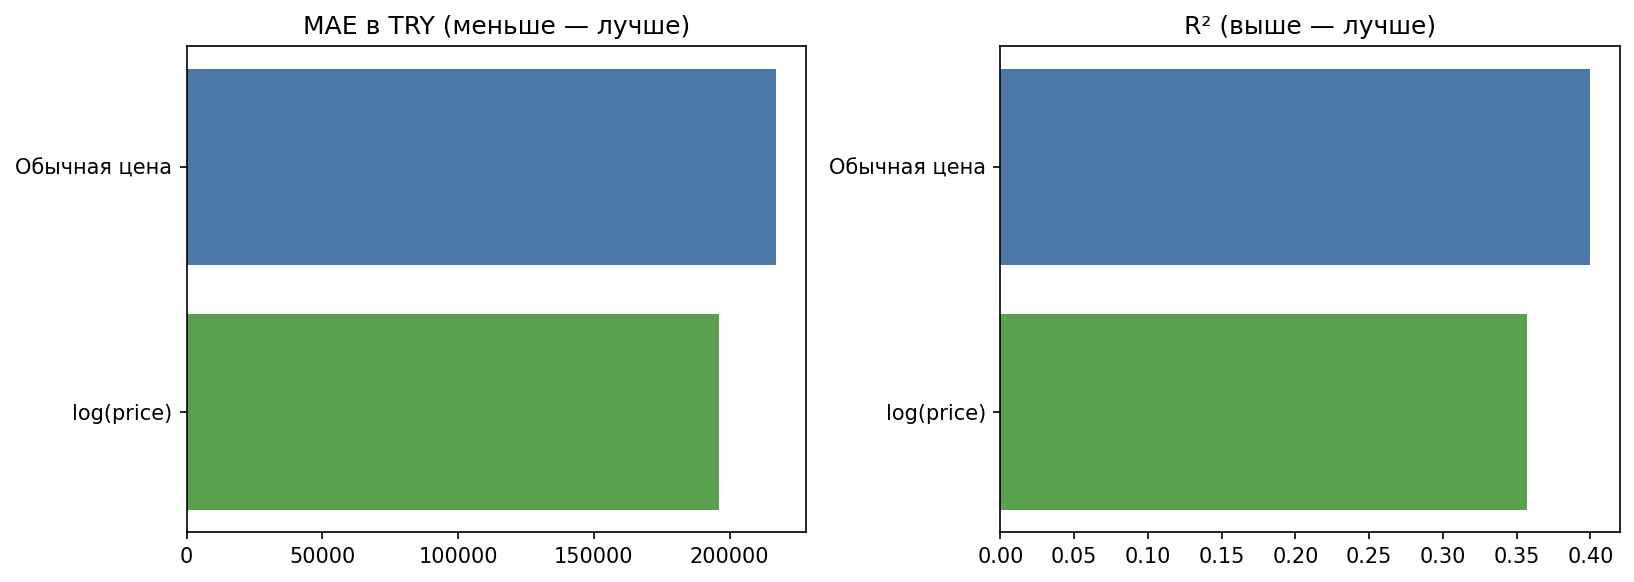

In [2]:
# Сравниваем основные метрики на исходной шкале цены.
fig,axes=plt.subplots(1,2,figsize=(11,4))
sns.barplot(data=log_target_results,x="MAE, TRY",y="Вариант",ax=axes[0],color="#4C78A8")
axes[0].set_title("MAE в TRY (меньше — лучше)")
sns.barplot(data=log_target_results,x="R²",y="Вариант",ax=axes[1],color="#59A14F")
axes[1].set_title("R² (выше — лучше)")
plt.tight_layout(); display(fig)

### Результат сравнения обычной цены и log(price)

На одной и той же полной validation вариант log(price) показал MAE **196 тыс. TRY** против **217 тыс. TRY** у обычной цели; медианная ошибка снизилась с **62 тыс. до 49 тыс. TRY**. R² при этом снизился с **0,400 до 0,357**, а RMSE вырос с **1,65 до 1,71 млн TRY**. Значит, логарифм улучшил типичную абсолютную ошибку, но не крупные промахи на дорогом хвосте.

Для объектов не дороже P90 train (750 тыс. TRY) log(price) также дал лучшие значения: MAE **69,6 тыс. против 96,5 тыс. TRY**, R² **0,136 против −3,083**. Это показывает, что логарифмирование помогает обычному сегменту; верхние дорогие ошибки остаются проблемой.

**Промежуточный вывод:** log(price) — перспективный кандидат, если важнее средняя ошибка типичных объявлений. Для основной модели решение пока не фиксируем: надо сравнить варианты также на отложенном test, которого мы здесь не касались. Экспонента после прогноза может давать систематическое занижение исходной средней цены; следующий контроль — проверить смещение остатков и при необходимости калибровку. Все значения относятся к очищенной выборке версии 1.6.

## Этап 3 по требованиям проекта: итоговое сравнение и финальная модель

Минимум три семейства моделей представлены линейной регрессией, одиночным деревом и XGBoost. Для каждой есть базовый вариант и вариант после поиска параметров на train с групповой кросс-валидацией. Дополнительный опыт с log(price) не заменяет обязательные модели. Далее сравниваются все варианты на одной validation в TRY; test остаётся нетронутым.

In [5]:
# Сводим обязательные модели и дополнительный вариант log(price) в одну таблицу.
required_comparison = comparison_full.copy()
required_comparison["Вариант"] = required_comparison["Модель"] + " — " + required_comparison["Вариант"]
log_row = log_target_results.iloc[log_target_results["MAE, TRY"].argmin()].copy()
log_row["Вариант"] = "XGBoost — log(price)"
log_row["Модель"] = "XGBoost"
log_row["Вариант модели"] = "Логарифмическая цель"
final_comparison = pd.concat([required_comparison, pd.DataFrame([log_row])], ignore_index=True, sort=False)
display(final_comparison[["Вариант","MAE, TRY","RMSE, TRY","MAPE, %","R²","Медианная ошибка, TRY"]].round(3))
final_comparison.to_csv(ROOT/"data"/"processed"/"stage3_final_comparison_main_v1.10.csv",index=False,encoding="utf-8-sig")

,Вариант,"MAE, TRY","RMSE, TRY","MAPE, %",R²,"Медианная ошибка, TRY"
0,Decision Tree — Базовая,258624.847,2330113.667,38.333,-0.195,56000.000
1,Decision Tree — После настройки,241692.414,1806029.417,42.346,0.282,68828.512
2,Linear Regression — Базовая,353203.435,1861668.678,89.567,0.237,152902.114
3,Linear Regression — После настройки,353235.545,1861658.304,89.584,0.237,152885.670
4,XGBoost — Базовая,217249.000,1651181.452,39.139,0.400,62063.422
5,XGBoost — После настройки,229007.471,1688767.744,44.578,0.372,72683.453
6,XGBoost — log(price),196032.638,1708996.499,27.683,0.357,49278.938


### Сравнение графиков моделей

На графиках представлены MAE и R² на одной validation. MAE показывает типичную абсолютную ошибку в TRY, R² — насколько модель объясняет разброс цен. Выбор не делаем только по одной метрике: дорогие редкие объекты сильно влияют на RMSE и R².

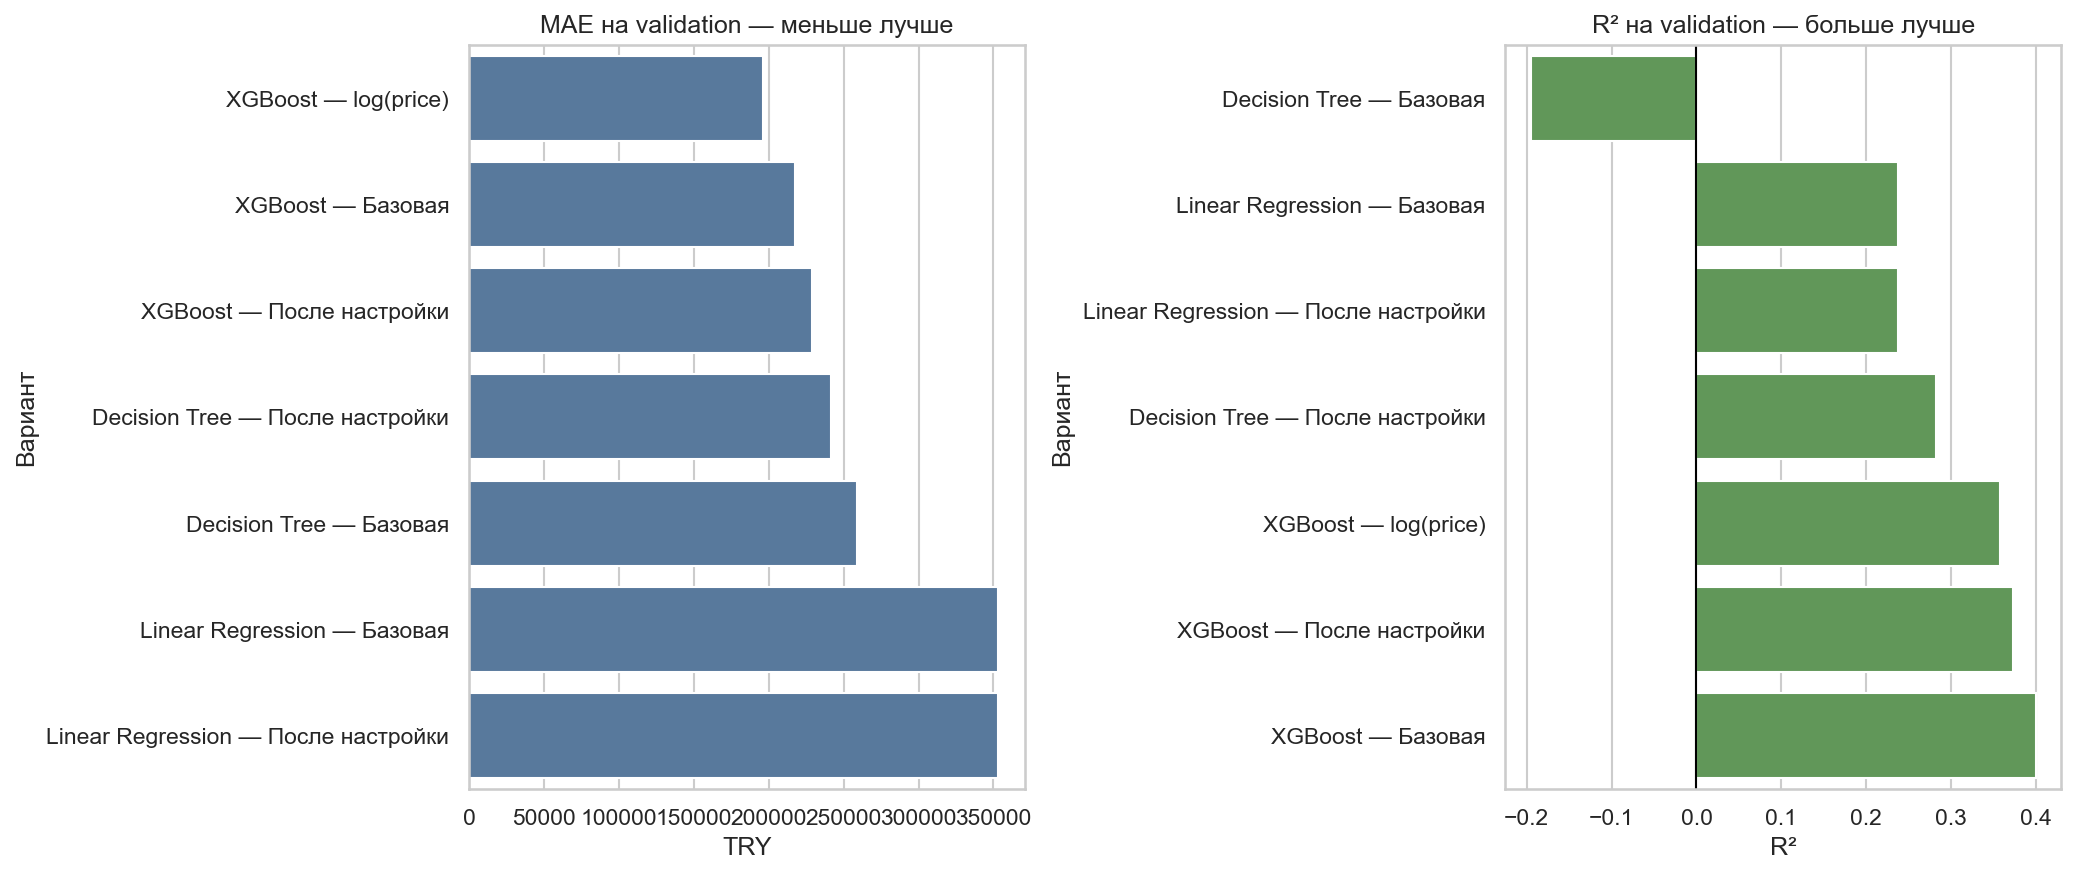

In [7]:
# Визуально сравниваем обязательные модели и log-вариант.
plot_data=final_comparison.dropna(subset=["MAE, TRY","R²"]).copy()
fig,axes=plt.subplots(1,2,figsize=(14,6))
sns.barplot(data=plot_data.sort_values("MAE, TRY"),x="MAE, TRY",y="Вариант",ax=axes[0],color="#4C78A8")
axes[0].set_title("MAE на validation — меньше лучше"); axes[0].set_xlabel("TRY")
sns.barplot(data=plot_data.sort_values("R²"),x="R²",y="Вариант",ax=axes[1],color="#59A14F")
axes[1].axvline(0,color="black",lw=1); axes[1].set_title("R² на validation — больше лучше")
plt.tight_layout(); display(fig)

### 3.4. Факт, прогноз и остатки для лучшего кандидата

По validation минимальная MAE у варианта XGBoost с логарифмической целевой ценой. Эти графики помогают увидеть систематическое смещение, разброс ошибок и влияние дорогих объявлений. Выбор пока предварительный: финальная проверка будет на test.

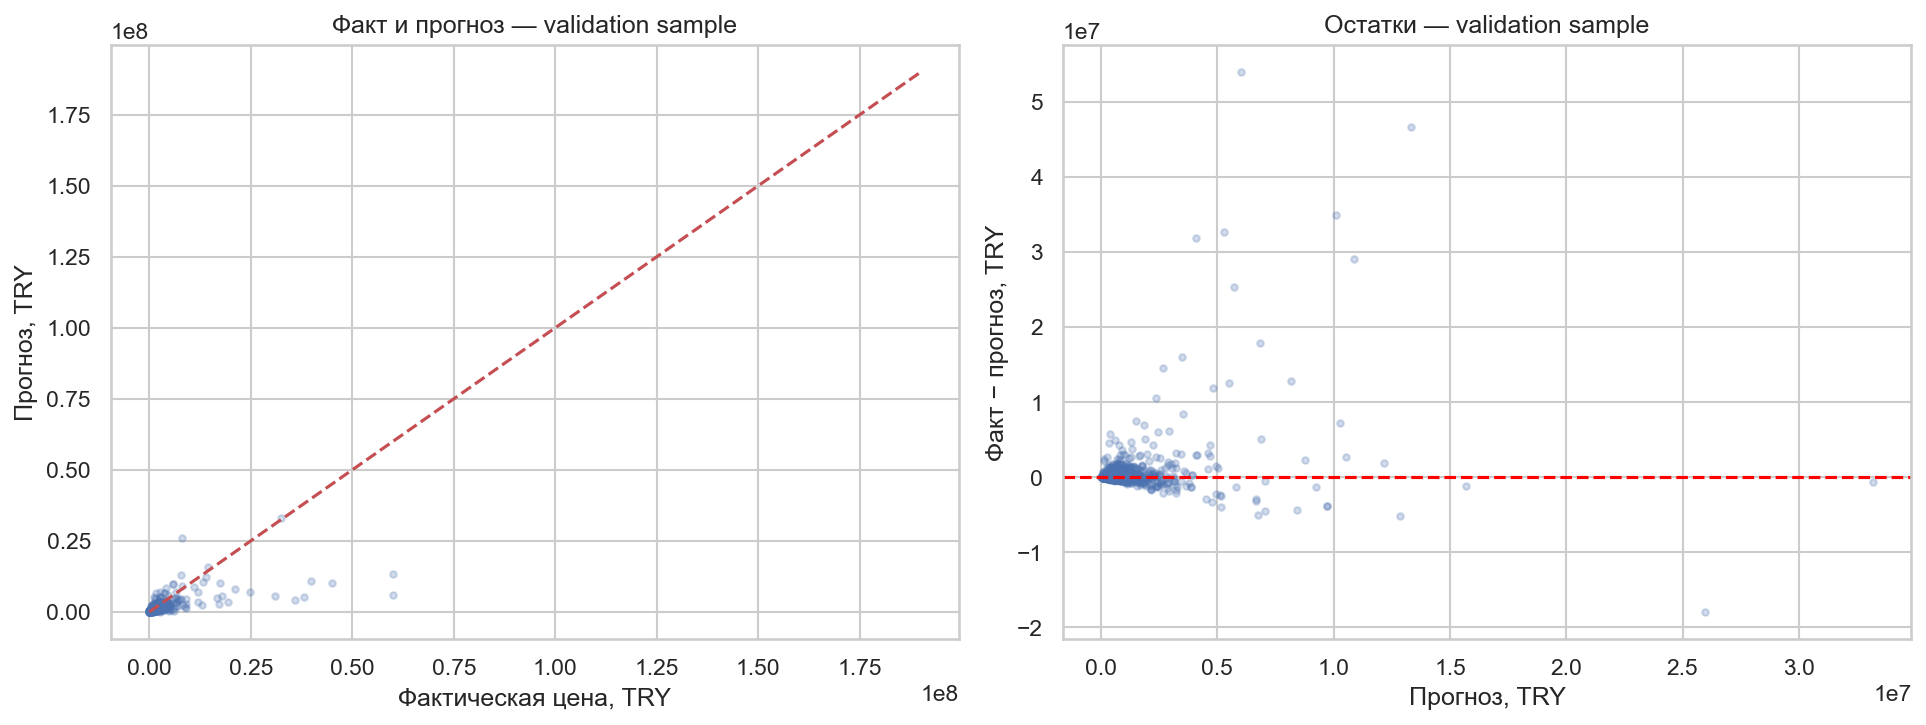

In [9]:
# Графики прогноза и ошибок; дорогие цены остаются видимыми.
residuals_log=y_cv_val.to_numpy()-log_predictions["log(price)"]
sample_rng=np.random.default_rng(42)
show_idx=np.sort(sample_rng.choice(len(y_cv_val),min(6000,len(y_cv_val)),replace=False))
fig,axes=plt.subplots(1,2,figsize=(13,5))
axes[0].scatter(y_cv_val.to_numpy()[show_idx],log_predictions["log(price)"][show_idx],s=10,alpha=.25)
limit=max(y_cv_val.max(),log_predictions["log(price)"].max()); axes[0].plot([0,limit],[0,limit],"r--")
axes[0].set(xlabel="Фактическая цена, TRY",ylabel="Прогноз, TRY",title="Факт и прогноз — sample validation")
axes[1].scatter(log_predictions["log(price)"][show_idx],residuals_log[show_idx],s=10,alpha=.25)
axes[1].axhline(0,color="red",linestyle="--")
axes[1].set(xlabel="Прогноз, TRY",ylabel="Факт − прогноз, TRY",title="Остатки — sample validation")
plt.tight_layout(); display(fig)

### Анализ важности признаков

Для XGBoost показываем gain-based importance как ориентир того, какие признаки модель использует при разбиениях. Это не доказывает причинно-следственную связь; взаимосвязанные признаки могут делить между собой важность.

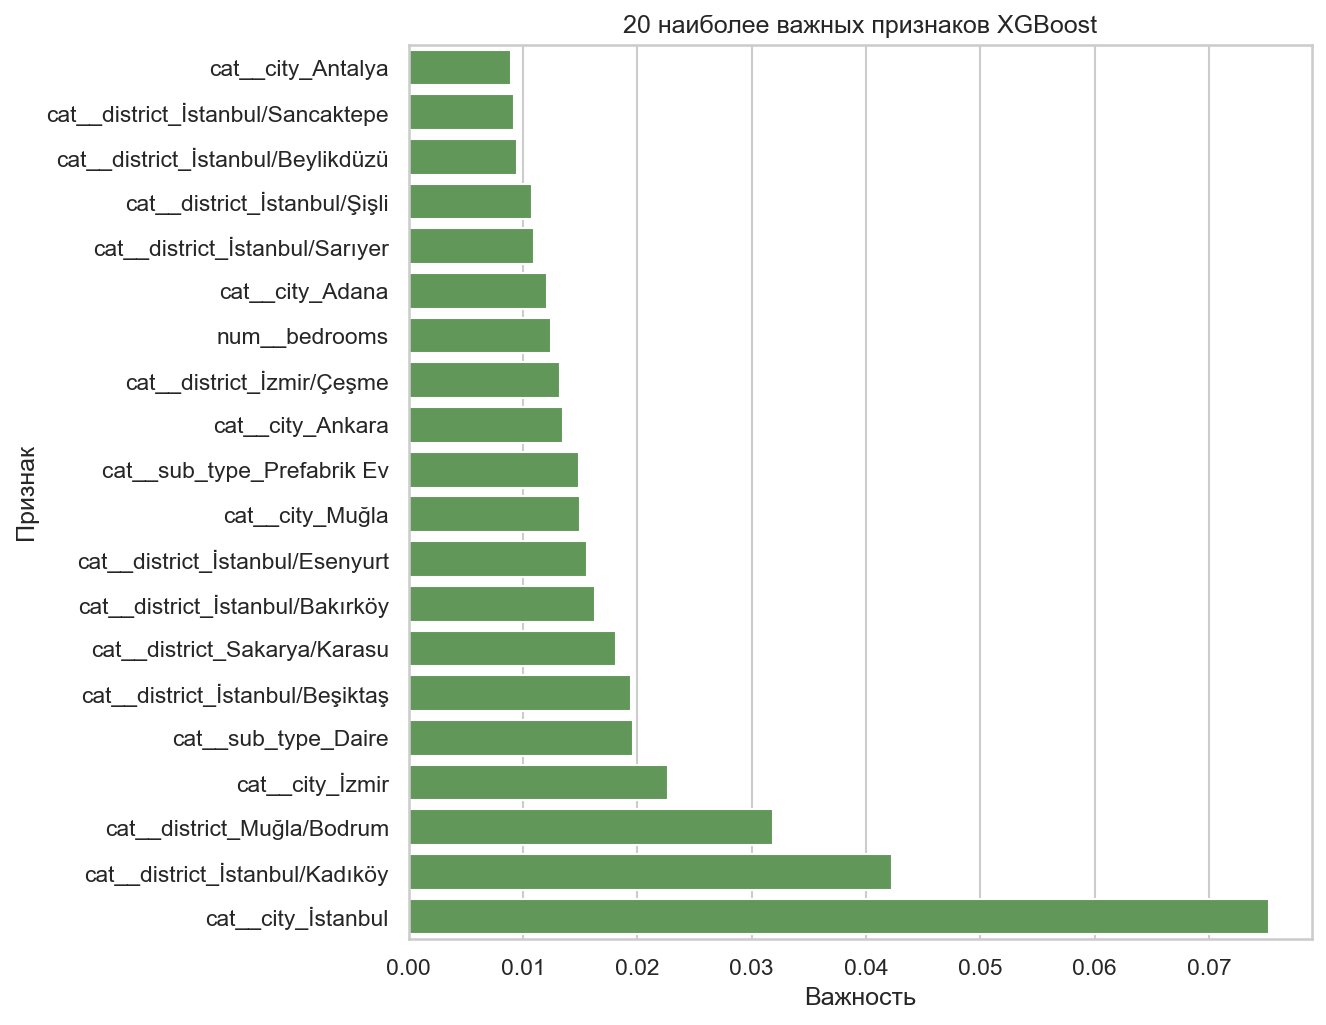

In [11]:
# Выводим признаки с наибольшей важностью в XGBoost.
final_xgb_model=log_models["log(price)"].named_steps["model"]
feature_names=log_models["log(price)"].named_steps["preprocessor"].get_feature_names_out()
importance=pd.DataFrame({"Признак":feature_names,"Важность":final_xgb_model.feature_importances_}).sort_values("Важность",ascending=False).head(20)
display(importance)
fig,ax=plt.subplots(figsize=(9,7)); sns.barplot(data=importance.sort_values("Важность"),x="Важность",y="Признак",ax=ax,color="#59A14F")
ax.set_title("20 наиболее важных признаков XGBoost"); plt.tight_layout(); display(fig)

### 3.5. Выбор и сохранение кандидата

Предварительный кандидат по validation — XGBoost с log(price): он дал наименьшую MAE и медианную ошибку, но уступил по R² и RMSE. Поэтому сохраняем его как кандидата, а не объявляем окончательно лучшим до оценки на test. Сохраняется весь sklearn Pipeline вместе с заполнением площади, кодированием категорий и моделью; при использовании прогноз переводится из логарифма обратно в TRY экспонентой.

In [13]:
# Сохраняем модель-кандидат и сведения о целевом преобразовании.
import joblib
artifact_dir=ROOT/"models"; artifact_dir.mkdir(parents=True,exist_ok=True)
artifact_path=artifact_dir/"xgboost_log_price_candidate_v1.10.joblib"
joblib.dump({"pipeline":log_models["log(price)"],"target_transform":"natural_log_price","inverse_transform":"numpy.exp","features":list(X_cv_train.columns),"currency":"TRY","status":"validation_candidate_not_tested"},artifact_path)
print("Кандидат сохранён:",artifact_path)
print("В приложении: pipeline.predict(X) возвращает log(price); цену в TRY получить через np.exp(...).")
print("Финальное решение и итоговые метрики фиксируем только после однократной проверки на test.")

Кандидат сохранён: C:\ForesightEstate\models\xgboost_log_price_candidate_v1.10.joblib
В приложении: pipeline.predict(X) возвращает log(price); цену в TRY получить через np.exp(...).
Финальное решение и итоговые метрики фиксируем только после однократной проверки на test.


### Итог по этапу 3

Проверены три обязательных семейства моделей: линейная регрессия, одиночное дерево и XGBoost; для каждой подготовлены базовый вариант и подбор параметров с CV на train. Все метрики сравниваются на одной validation; test не участвовал в выборе. По MAE предварительно выигрывает XGBoost с log(price), однако по RMSE и R² обычный XGBoost лучше. Кандидат сохранён с полным преобразующим пайплайном; окончательный выбор зависит от результата на test и требуемого сценария приложения.